<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# GOOGLE DRIVE PERSISTENT STORAGE SETUP - SAFE VERSION
# =========================================================

from google.colab import drive
import os
import shutil

# 1. COBA MOUNT DRIVE LAGI

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

assert os.path.exists("/content/drive/MyDrive"), \
    "Google Drive belum mounted"

SAVE_DIR = "/content/drive/MyDrive/router_classifier"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Persistent storage OK:", SAVE_DIR)

DRIVE_MOUNT = "/content/drive"
SAVE_DIR = "/content/router_classifier_temp"

drive_ok = False

try:
    drive.mount(
        DRIVE_MOUNT,
        force_remount=False
    )

    SAVE_DIR = (
        f"{DRIVE_MOUNT}/MyDrive/router_classifier"
    )

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )

    drive_ok = True

    print("Google Drive mounted.")
    print("Persistent SAVE_DIR:", SAVE_DIR)

except Exception as e:

    print("WARNING: Google Drive gagal dimount.")
    print(type(e).__name__, e)

    print()
    print("Fallback sementara ke /content.")
    print("DATA BISA HILANG jika runtime restart.")

    SAVE_DIR = "/content/router_classifier_temp"

    os.makedirs(
        SAVE_DIR,
        exist_ok=True
    )


# =========================================================
# PATH CONFIG
# =========================================================

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

BASE_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"
CURRENT_DATASET_PATH = f"{SAVE_DIR}/router_dataset_current.csv"
CURRENT_MODEL_PATH = f"{SAVE_DIR}/router_classifier_current.joblib"
ROUND_LOG_PATH = f"{SAVE_DIR}/router_tuning_rounds.csv"


print()
print("=" * 60)
print("STORAGE STATUS")
print("=" * 60)

print("Drive mounted :", drive_ok)
print("SAVE_DIR      :", SAVE_DIR)

print()

Mounted at /content/drive
Persistent storage OK: /content/drive/MyDrive/router_classifier
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Persistent SAVE_DIR: /content/drive/MyDrive/router_classifier

STORAGE STATUS
Drive mounted : True
SAVE_DIR      : /content/drive/MyDrive/router_classifier



In [2]:
# 1. Install library
!pip install -q datasets pandas requests tqdm scikit-learn sentence-transformers joblib

In [3]:
# 2. Download dataset Indonesia

from datasets import load_dataset

ds = load_dataset(
    "ilhamfadheel/alpaca-cleaned-indonesian",
    split="train"
)

print(ds)
print(ds[0])

README.md:   0%|          | 0.00/10.0k [00:00<?, ?B/s]

AlpacaCleaned_translated_id.json: reconstructing file:   0%|          |  0.00B / 35.3MB            

AlpacaCleaned_translated_id.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/45631 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 45631
})
{'instruction': 'Sebutkan tiga senyawa organik.', 'input': '', 'output': 'Tiga senyawa organik adalah glukosa (C6H12O6), metana (CH4), dan etanol (C2H5OH).'}


In [4]:
# # Ambil 5.000 prompt dulu
# SAMPLE_SIZE = 5000

# ds_small = ds.shuffle(seed=42).select(
#     range(min(SAMPLE_SIZE, len(ds)))
# )

# def build_prompt(row):
#     instruction = row["instruction"].strip()
#     input_text = row["input"].strip()

#     if input_text:
#         return instruction + "\n" + input_text

#     return instruction

# prompts = [build_prompt(x) for x in ds_small]

# print("Jumlah prompt:", len(prompts))

# for x in prompts[:5]:
#     print("\n---")
#     print(x)

In [5]:
# 4. Buat label router SIMPLE
# Fakta sederhana, lookup, klasifikasi sederhana,
# jawaban singkat, operasi mudah.

# GENERAL
# Penjelasan umum yang tidak membutuhkan reasoning berat.

# REASONING
# Analisis, matematika, planning, comparison,
# trade-off, deduksi, multi-step problem.

# CODING_SIMPLE
# Generate snippet sederhana, regex, SQL sederhana,
# fungsi kecil, syntax.

# CODING_COMPLEX
# Debugging kompleks, architecture, multi-file,
# race condition, performance, security review.

# TRANSFORM
# Translation, summarization, rewrite,
# extract, shorten, formatting.

# CREATIVE
# Story, brainstorming kreatif, slogan,
# dialog, ide kreatif.

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

In [6]:
# 5. Konfigurasi API teacher
import os

BASE_URL = "https://openrouter.ai/api/v1/chat/completions"
API_KEY = "ISI_API_KEY"
MODEL = "openrouter/free"

TEMPERATURE = 0
TIMEOUT = 90

In [7]:
from google.colab import userdata
API_KEY = userdata.get('OPEN_ROUTER')

In [8]:
# 6. Teacher prompt
SYSTEM_PROMPT = """
You are labeling user prompts for an AI model router.

Classify each prompt into EXACTLY ONE label:

SIMPLE
- Simple factual questions
- Easy lookup
- Basic classification
- Very short/simple task
- Does not require substantial reasoning

GENERAL
- General explanation
- Normal knowledge question
- Moderate general assistant task
- Does not clearly belong to another category

REASONING
- Mathematics
- Multi-step reasoning
- Planning
- Comparison and trade-offs
- Analysis
- Deduction
- Complex decision making

CODING_SIMPLE
- Small code snippets
- Simple functions
- Regex
- Basic SQL
- Syntax questions
- Straightforward programming tasks

CODING_COMPLEX
- Complex debugging
- Software architecture
- Multi-component systems
- Race conditions
- Security/code review
- Performance optimization
- Complex implementation

TRANSFORM
- Translation
- Summarization
- Rewrite
- Shortening
- Extraction
- Reformatting
- Changing an existing text without requiring substantial new reasoning

CREATIVE
- Story writing
- Creative brainstorming
- Dialogue
- Slogans
- Fiction
- Creative ideation

Important rules:

1. Classify based on USER INTENT, not individual keywords.
2. The prompt may be Indonesian, English, or mixed Indonesian-English.
3. Technical words do NOT automatically mean CODING.
4. Mentioning a language such as "Bahasa Inggris" does NOT automatically mean TRANSFORM.
5. "Explain" does NOT automatically mean REASONING.
6. Choose CODING_COMPLEX only if strong technical reasoning or debugging is actually required.
7. Use SIMPLE for genuinely easy tasks.
8. Return valid JSON only.

Output schema:

{
  "label": "ONE_LABEL",
  "difficulty": 1,
  "confidence": 0.95
}

difficulty must be integer 1-5.
confidence must be number 0-1.
"""

In [9]:
# 7. Fungsi call API
import requests
import time

def call_teacher(prompt):
    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json"
    }

    payload = {
        "model": MODEL,
        "temperature": 0,
        "messages": [
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    }

    print("  -> POST", BASE_URL)
    print("  -> model:", MODEL)

    start = time.time()

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,

        # jangan 90 detik dulu untuk debugging
        timeout=(10, 30)
    )

    print(
        f"  <- HTTP {response.status_code}"
        f" ({time.time() - start:.2f}s)"
    )

    response.raise_for_status()

    data = response.json()

    return data["choices"][0]["message"]["content"]

In [10]:
# 8. Parser JSON yang lebih tahan error

import re

import json
import re

def parse_teacher_output(text):
    if not text:
        raise ValueError("Teacher mengembalikan response kosong")

    text = text.strip()

    # Hapus markdown fence kalau model memberi ```json
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.I)
    text = re.sub(r"\s*```$", "", text)

    # Cari object JSON
    match = re.search(r'\{[\s\S]*?\}', text)

    if not match:
        raise ValueError(
            f"Teacher tidak mengembalikan JSON. Raw: {text[:300]!r}"
        )

    try:
        data = json.loads(match.group())
    except json.JSONDecodeError as e:
        raise ValueError(
            f"JSON teacher rusak: {match.group()[:300]}"
        ) from e

    label = data.get("label")

    try:
        difficulty = int(data.get("difficulty"))
        confidence = float(data.get("confidence"))
    except (TypeError, ValueError):
        raise ValueError(
            f"difficulty/confidence invalid: {data}"
        )

    if label not in LABELS:
        raise ValueError(f"Label invalid: {label}")

    if not 1 <= difficulty <= 5:
        raise ValueError(f"Difficulty invalid: {difficulty}")

    if not 0 <= confidence <= 1:
        raise ValueError(f"Confidence invalid: {confidence}")

    return {
        "label": label,
        "difficulty": difficulty,
        "confidence": confidence,
    }

In [11]:
# 9. Tes 1 prompt dulu
import json

test_prompt = """
review architecture backend saya dan cari kemungkinan
race condition serta bottleneck performance
"""

raw = call_teacher(test_prompt)

print("RAW:")
print(raw)

parsed = parse_teacher_output(raw)

print("\nPARSED:")
print(parsed)

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.73s)
RAW:
{
  "label": "REASONING",
  "difficulty": 4,
  "confidence": 0.96
}

PARSED:
{'label': 'REASONING', 'difficulty': 4, 'confidence': 0.96}


In [12]:
# 11. Teacher labeling + checkpoint
import pandas as pd
import os

CHECKPOINT_PATH = "/content/router_teacher_checkpoint.csv"

if os.path.exists(CHECKPOINT_PATH):
    df_result = pd.read_csv(CHECKPOINT_PATH)

    print(
        "Resume checkpoint:",
        len(df_result),
        "prompt"
    )

else:
    df_result = pd.DataFrame(
        columns=[
            "prompt",
            "label",
            "difficulty",
            "confidence",
            "status"
        ]
    )

    print("Checkpoint belum ada, mulai dari 0")

print(df_result.head())
print("Rows:", len(df_result))

Checkpoint belum ada, mulai dari 0
Empty DataFrame
Columns: [prompt, label, difficulty, confidence, status]
Index: []
Rows: 0


In [13]:
# #12. Loop labeling DEPRECTATED FLOW

# from tqdm.auto import tqdm
# import time

# START_INDEX = len(df_result)

# SAVE_EVERY = 20
# MAX_RETRIES = 3

# results = df_result.to_dict("records")

# print("Mulai dari index:", START_INDEX)
# print("Total prompt:", len(prompts))

# for i in tqdm(
#     range(START_INDEX, len(prompts)),
#     initial=START_INDEX,
#     total=len(prompts)
# ):

#     prompt = prompts[i]
#     success = False

#     for attempt in range(MAX_RETRIES):
#         try:
#             raw = call_teacher(prompt)
#             parsed = parse_teacher_output(raw)

#             results.append({
#                 "prompt": prompt,
#                 "label": parsed["label"],
#                 "difficulty": parsed["difficulty"],
#                 "confidence": parsed["confidence"],
#                 "status": "ok"
#             })

#             success = True
#             break

#         except Exception as e:
#             print(
#                 f"\nError index {i}, "
#                 f"attempt {attempt + 1}/{MAX_RETRIES}: "
#                 f"{type(e).__name__}: {e}"
#             )

#             try:
#                 print("RAW RESPONSE:", raw[:500])
#             except:
#                 pass

#         time.sleep(2 * (attempt + 1))

#     if not success:
#         results.append({
#             "prompt": prompt,
#             "label": None,
#             "difficulty": None,
#             "confidence": None,
#             "status": "error"
#         })

#     if (
#         (i + 1) % SAVE_EVERY == 0
#         or i == len(prompts) - 1
#     ):
#         pd.DataFrame(results).to_csv(
#             CHECKPOINT_PATH,
#             index=False
#         )

#         print(
#             f"\nCheckpoint saved: "
#             f"{len(results)}/{len(prompts)}"
#         )

# print("Labeling selesai")

In [14]:
SAVE_DIR = "/content/drive/MyDrive/router_classifier"

CHECKPOINT_PATH = f"{SAVE_DIR}/router_teacher_checkpoint.csv"
EXTRA_ALL_PATH = f"{SAVE_DIR}/router_teacher_extra_all.csv"
CURRENT_DATASET_PATH = f"{SAVE_DIR}/router_dataset_current.csv"
CURRENT_MODEL_PATH = f"{SAVE_DIR}/router_classifier_current.joblib"
ROUND_LOG_PATH = f"{SAVE_DIR}/router_tuning_rounds.csv"

import os
import pandas as pd

print("Checkpoint path:", CHECKPOINT_PATH)
print("Exists:", os.path.exists(CHECKPOINT_PATH))

if os.path.exists(CHECKPOINT_PATH):
    df = pd.read_csv(CHECKPOINT_PATH)
    print("Total tersimpan:", len(df))
else:
    print("Checkpoint belum ditemukan.")

Checkpoint path: /content/drive/MyDrive/router_classifier/router_teacher_checkpoint.csv
Exists: True
Total tersimpan: 100


In [15]:
# 13. Load hasil final LOAD CHECKPOINT / FINAL RESULT

import pandas as pd

df = pd.read_csv(CHECKPOINT_PATH)

print("Total tersimpan:", len(df))
print()

print("Status:")
print(df["status"].value_counts(dropna=False))
print()

print("Label:")
print(df["label"].value_counts(dropna=False))
print()

print("Shape:", df.shape)

Total tersimpan: 100

Status:
status
ok    100
Name: count, dtype: int64

Label:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Shape: (100, 5)


In [16]:
# 14. Hapus request yang gagal

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean = df[
    df["status"] == "ok"
].copy()

df_clean.to_csv(
    "/content/router_seed_indonesia.csv",
    index=False
)

print("Seed Indonesia:", len(df_clean))

Seed Indonesia: 100


In [17]:
# 15. Lihat distribusi label

print(
    df_clean["label"].value_counts()
)

print()

print(
    df_clean["label"]
    .value_counts(normalize=True)
    .round(3)
)

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

label
SIMPLE           0.35
CREATIVE         0.23
GENERAL          0.22
TRANSFORM        0.13
REASONING        0.05
CODING_SIMPLE    0.02
Name: proportion, dtype: float64


In [18]:
# 16. Filter confidence rendah

MIN_CONFIDENCE = 0.80

df_high = df_clean[
    df_clean["confidence"] >= MIN_CONFIDENCE
].copy()

print(
    "High confidence:",
    len(df_high)
)

print()

print(
    df_high["label"].value_counts()
)

High confidence: 100

label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [19]:
# 17. Lihat prompt yang teacher tidak yakin

uncertain = df_clean.sort_values(
    "confidence"
)

print(
    uncertain[
        [
            "prompt",
            "label",
            "difficulty",
            "confidence"
        ]
    ]
    .head(30)
    .to_string(index=False)
)

                                                                                                                                                                                                                                                                                                                                     prompt         label  difficulty  confidence
                                                                                                                                                                                                                                                                                    Buat iklan lowongan pekerjaan untuk copy editor online.      CREATIVE           2        0.85
                                                                                                                                                                                                                                                             Hasilka

In [20]:
# 18. Lihat contoh setiap kategori

for label in LABELS:

    print("\n")
    print("=" * 70)
    print(label)
    print("=" * 70)

    samples = (
        df_high[
            df_high["label"] == label
        ]
        .sample(
            min(
                10,
                len(
                    df_high[
                        df_high["label"]
                        == label
                    ]
                )
            ),
            random_state=42
        )
    )

    for _, row in samples.iterrows():

        print(
            f"\n[{row['confidence']:.2f}]",
            row["prompt"][:300]
        )



SIMPLE

[0.95] Temukan kelipatan persekutuan terkecil dari 15 dan 20

[0.95] Tulis persamaan untuk menghitung total biaya suatu produk.
Harga produk = $24
Kuantitas = 3
Biaya pengiriman = $8

[0.95] Jelaskan arti frasa "carpe diem".

[0.95] Kelompokkan kata-kata menurut bagian pidatonya.
Kuat, panjang, apel

[0.95] Bacalah pengamatan berikut dan beri label sebagai kekuatan atau kelemahan.
Situs web ini ramah pengguna dan mudah dinavigasi.

[0.96] Sebutkan ciri-ciri mobil tahun 1950an.

[0.95] Pilihlah kalimat yang paling mencerminkan pendapat yang diberikan
Saya lebih suka melakukan aktivitas lain selain berbelanja di akhir pekan

[0.95] Cocokkan setiap item dengan salah satu dari empat musim.
Salju, Berkemah, Pantai, Anggur

[0.98] Kategorikan kata berikut ke dalam kelas kata yang sesuai.
Cantik

[0.95] Jika diberi resep, sarankan hidangan yang sesuai untuk menyajikannya.
Resep: Lasagna Keju


GENERAL

[0.93] Jelaskan faktor-faktor yang berkontribusi terhadap krisis ekonomi global s

In [21]:
# 19. Export teacher dataset
FINAL_DATASET = (
    "/content/router_teacher_labeled.csv"
)

df_high.to_csv(
    FINAL_DATASET,
    index=False
)

print(FINAL_DATASET)

/content/router_teacher_labeled.csv


In [22]:
# 20. Training classifier baru

from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/"
    "paraphrase-multilingual-MiniLM-L12-v2"
)

X = embedding_model.encode(
    df_high["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y = df_high["label"].values

print(X.shape)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

(100, 384)


In [23]:
# 21. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    len(X_train),
    len(X_test)
)

80 20


In [24]:
# 22. Train Logistic Regression
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(
    max_iter=2000,
    random_state=42
)

classifier.fit(
    X_train,
    y_train
)

print("Done")

Done


In [25]:
# 23. Evaluate

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pred = classifier.predict(
    X_test
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print()

print(
    classification_report(
        y_test,
        pred,
        digits=3
    )
)

Accuracy: 0.65

              precision    recall  f1-score   support

    CREATIVE      1.000     0.800     0.889         5
     GENERAL      0.667     0.500     0.571         4
   REASONING      0.000     0.000     0.000         1
      SIMPLE      0.538     1.000     0.700         7
   TRANSFORM      0.000     0.000     0.000         3

    accuracy                          0.650        20
   macro avg      0.441     0.460     0.432        20
weighted avg      0.572     0.650     0.582        20



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
# 24. Confusion matrix
from sklearn.metrics import confusion_matrix

labels_sorted = list(
    classifier.classes_
)

cm = confusion_matrix(
    y_test,
    pred,
    labels=labels_sorted
)

cm_df = pd.DataFrame(
    cm,
    index=labels_sorted,
    columns=labels_sorted
)

print(cm_df)

               CODING_SIMPLE  CREATIVE  GENERAL  REASONING  SIMPLE  TRANSFORM
CODING_SIMPLE              0         0        0          0       0          0
CREATIVE                   0         4        0          0       1          0
GENERAL                    0         0        2          0       2          0
REASONING                  0         0        1          0       0          0
SIMPLE                     0         0        0          0       7          0
TRANSFORM                  0         0        0          0       3          0


In [27]:
# 25. Test prompt Indonesia nyata
test_prompts = [
    "berapa 15 persen dari 500",

    "jelaskan fungsi docker compose",

    "bandingkan REST dan GraphQL "
    "untuk backend aplikasi besar",

    "buat regex untuk validasi email",

    "debug kenapa service systemd saya "
    "restart terus dan cek kemungkinan "
    "race condition",

    "ringkas tulisan ini menjadi 5 poin",

    "terjemahkan kalimat ini ke bahasa jepang",

    "buat cerita pendek tentang robot kecil",

    "kenapa request ke API direct cepat "
    "tapi lewat router jadi lambat",

    "review architecture backend saya, "
    "analisis bottleneck, retry strategy, "
    "dan desain ulang flow request"
]

emb = embedding_model.encode(
    test_prompts,
    normalize_embeddings=True
)

prediction = classifier.predict(
    emb
)

probability = classifier.predict_proba(
    emb
)

for prompt, label, probs in zip(
    test_prompts,
    prediction,
    probability
):

    confidence = probs.max()

    print("\nPROMPT:")
    print(prompt)

    print(
        "ROUTE:",
        label
    )

    print(
        "CONFIDENCE:",
        round(
            float(confidence),
            3
        )
    )


PROMPT:
berapa 15 persen dari 500
ROUTE: SIMPLE
CONFIDENCE: 0.448

PROMPT:
jelaskan fungsi docker compose
ROUTE: SIMPLE
CONFIDENCE: 0.433

PROMPT:
bandingkan REST dan GraphQL untuk backend aplikasi besar
ROUTE: SIMPLE
CONFIDENCE: 0.384

PROMPT:
buat regex untuk validasi email
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
debug kenapa service systemd saya restart terus dan cek kemungkinan race condition
ROUTE: SIMPLE
CONFIDENCE: 0.383

PROMPT:
ringkas tulisan ini menjadi 5 poin
ROUTE: SIMPLE
CONFIDENCE: 0.52

PROMPT:
terjemahkan kalimat ini ke bahasa jepang
ROUTE: SIMPLE
CONFIDENCE: 0.34

PROMPT:
buat cerita pendek tentang robot kecil
ROUTE: SIMPLE
CONFIDENCE: 0.336

PROMPT:
kenapa request ke API direct cepat tapi lewat router jadi lambat
ROUTE: SIMPLE
CONFIDENCE: 0.375

PROMPT:
review architecture backend saya, analisis bottleneck, retry strategy, dan desain ulang flow request
ROUTE: GENERAL
CONFIDENCE: 0.399


In [28]:
# # 26. Simpan classifier
import joblib

MODEL_PATH = (
    "/content/router_classifier_v2.joblib"
)

joblib.dump(
    classifier,
    MODEL_PATH
)

print(MODEL_PATH)

print(df_high["label"].value_counts())

/content/router_classifier_v2.joblib
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64


In [29]:
# 27. TARGET BALANCE

TARGET_PER_LABEL = 60

current_counts = df_high["label"].value_counts()

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE"
]

needed = {}

for label in LABELS:
    current = int(current_counts.get(label, 0))
    needed[label] = max(0, TARGET_PER_LABEL - current)

print("Current:")
print(current_counts)

print("\nNeed additional:")
for label, count in needed.items():
    print(label, ":", count)

Current:
label
SIMPLE           35
CREATIVE         23
GENERAL          22
TRANSFORM        13
REASONING         5
CODING_SIMPLE     2
Name: count, dtype: int64

Need additional:
SIMPLE : 25
GENERAL : 38
REASONING : 55
CODING_SIMPLE : 58
CODING_COMPLEX : 60
TRANSFORM : 47
CREATIVE : 37


In [30]:
# 28. EXTRA PROMPTS

extra_prompts = [
    # CODING_SIMPLE
    "buat regex untuk validasi email",
    "buat function python untuk parsing json",
    "buat query SQL untuk mengambil 10 user terbaru",
    "buat fungsi javascript untuk debounce",
    "buat contoh request fetch API sederhana",

    # CODING_COMPLEX
    "debug kenapa service systemd restart terus setelah dependency timeout",
    "review architecture microservice dan cari race condition",
    "analisis bottleneck concurrency pada worker queue",
    "review strategi retry dan circuit breaker untuk API yang sering gagal",
    "analisis security dan performance flow authentication"
]

print("Extra prompts:", len(extra_prompts))

Extra prompts: 10


In [31]:
# 29. TEACHER LABEL EXTRA

extra_results = []

for i, prompt in enumerate(extra_prompts, start=1):

    print(f"\n[{i}/{len(extra_prompts)}]")

    try:
        raw = call_teacher(prompt)
        parsed = parse_teacher_output(raw)

        extra_results.append({
            "prompt": prompt,
            "label": parsed["label"],
            "difficulty": parsed["difficulty"],
            "confidence": parsed["confidence"],
            "status": "ok"
        })

        print(parsed)

    except Exception as e:
        print("ERROR:", e)

        extra_results.append({
            "prompt": prompt,
            "label": None,
            "difficulty": None,
            "confidence": None,
            "status": "error"
        })


[1/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.11s)
ERROR: Teacher tidak mengembalikan JSON. Raw: 'User Safety: safe'

[2/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (18.13s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[3/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.88s)
{'label': 'CODING_SIMPLE', 'difficulty': 1, 'confidence': 0.95}

[4/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (12.85s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[5/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.05s)
{'label': 'CODING_SIMPLE', 'difficulty': 2, 'confidence': 0.95}

[6/10]
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 

In [32]:
# 30. SAVE EXTRA DATA

df_extra = pd.DataFrame(extra_results)

EXTRA_PATH = "/content/router_teacher_extra.csv"

df_extra.to_csv(
    EXTRA_PATH,
    index=False
)

print("Saved:", EXTRA_PATH)
print()
print(df_extra["label"].value_counts(dropna=False))

Saved: /content/router_teacher_extra.csv

label
CODING_SIMPLE    4
REASONING        4
None             1
GENERAL          1
Name: count, dtype: int64


In [33]:
# 31. MERGE OLD + EXTRA

df_old = df_high.copy()

df_new = pd.read_csv(
    "/content/router_teacher_extra.csv"
)

df_new = df_new[
    (df_new["status"] == "ok") &
    (df_new["confidence"] >= 0.80)
].copy()

df_balanced = pd.concat(
    [df_old, df_new],
    ignore_index=True
)

df_balanced = df_balanced.drop_duplicates(
    subset=["prompt"]
)

print("Total:", len(df_balanced))
print()
print(df_balanced["label"].value_counts())

Total: 109

label
SIMPLE           35
GENERAL          23
CREATIVE         23
TRANSFORM        13
REASONING         9
CODING_SIMPLE     6
Name: count, dtype: int64


In [34]:
# 32. RETRAIN V3 - SAFE VERSION


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# cek distribusi
counts = df_balanced["label"].value_counts()

print("Distribusi sebelum filter:")
print(counts)
print()

# hanya kelas dengan minimal 2 contoh
valid_labels = counts[counts >= 2].index

df_v3 = df_balanced[
    df_balanced["label"].isin(valid_labels)
].copy()

print("Distribusi setelah filter:")
print(df_v3["label"].value_counts())
print()

# embedding ulang
X_v3 = embedding_model.encode(
    df_v3["prompt"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y_v3 = df_v3["label"].values

# split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3,
    y_v3,
    test_size=0.2,
    random_state=42,
    stratify=y_v3
)

# train
classifier_v3 = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

classifier_v3.fit(
    X_train_v3,
    y_train_v3
)

# evaluate
pred_v3 = classifier_v3.predict(X_test_v3)

print(
    classification_report(
        y_test_v3,
        pred_v3,
        digits=3,
        zero_division=0
    )
)

Distribusi sebelum filter:
label
SIMPLE           35
GENERAL          23
CREATIVE         23
TRANSFORM        13
REASONING         9
CODING_SIMPLE     6
Name: count, dtype: int64

Distribusi setelah filter:
label
SIMPLE           35
GENERAL          23
CREATIVE         23
TRANSFORM        13
REASONING         9
CODING_SIMPLE     6
Name: count, dtype: int64



Batches:   0%|          | 0/2 [00:00<?, ?it/s]

               precision    recall  f1-score   support

CODING_SIMPLE      0.333     1.000     0.500         1
     CREATIVE      0.571     0.800     0.667         5
      GENERAL      1.000     0.200     0.333         5
    REASONING      1.000     1.000     1.000         2
       SIMPLE      0.571     0.571     0.571         7
    TRANSFORM      0.500     0.500     0.500         2

     accuracy                          0.591        22
    macro avg      0.663     0.679     0.595        22
 weighted avg      0.690     0.591     0.568        22



In [35]:
print(df_balanced["label"].value_counts())

label
SIMPLE           35
GENERAL          23
CREATIVE         23
TRANSFORM        13
REASONING         9
CODING_SIMPLE     6
Name: count, dtype: int64


In [42]:
# =========================================================
# AUTO TUNING SYSTEM - IMPROVED FULL VERSION
# =========================================================

import os
import re
import json
import time
import joblib
import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)


# =========================================================
# 1. CONFIG
# =========================================================

MIN_CONFIDENCE = 0.80

RANDOM_STATE = 42

VALIDATION_SIZE = 0.20

GRID_C_VALUES = [
    0.05,
    0.10,
    0.30,
    0.50,
    1.00,
    2.00,
    3.00,
    5.00,
    10.00,
]


LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE",
]


# =========================================================
# TARGET NORMAL DATASET
# =========================================================

TARGET_PER_LABEL = {
    "SIMPLE": 60,
    "GENERAL": 70,
    "REASONING": 75,
    "CODING_SIMPLE": 50,
    "CODING_COMPLEX": 60,
    "TRANSFORM": 50,
    "CREATIVE": 40,
}


# =========================================================
# EXTRA HARD-BOUNDARY TARGET
#
# Ini bukan total target.
# Ini jumlah tambahan yang boleh digenerate untuk kelas
# yang masih sering salah.
# =========================================================

HARD_BOUNDARY_BATCH = {
    "SIMPLE": 12,
    "GENERAL": 12,
    "REASONING": 20,
    "CODING_SIMPLE": 8,
    "CODING_COMPLEX": 15,
    "TRANSFORM": 8,
    "CREATIVE": 8,
}


# Minimal recall supaya kelas dianggap sehat.
MIN_CLASS_RECALL = 0.70


# =========================================================
# CONFUSION BOUNDARIES
# =========================================================

CONFUSION_BOUNDARIES = {

    "SIMPLE": [
        "GENERAL",
        "TRANSFORM",
        "CREATIVE",
        "REASONING",
    ],

    "GENERAL": [
        "SIMPLE",
        "REASONING",
        "CODING_COMPLEX",
    ],

    "REASONING": [
        "CODING_COMPLEX",
        "GENERAL",
    ],

    "CODING_SIMPLE": [
        "REASONING",
        "CODING_COMPLEX",
    ],

    "CODING_COMPLEX": [
        "REASONING",
        "GENERAL",
        "CODING_SIMPLE",
    ],

    "TRANSFORM": [
        "SIMPLE",
        "CREATIVE",
    ],

    "CREATIVE": [
        "TRANSFORM",
        "SIMPLE",
    ],
}


# =========================================================
# CATEGORY DESCRIPTIONS
# =========================================================

CATEGORY_DESCRIPTIONS = {

    "SIMPLE":
        "Simple factual questions, easy lookup, simple calculation, "
        "basic classification, definitions, and short easy tasks. "
        "The task should require very little reasoning.",

    "GENERAL":
        "Normal general assistant questions and explanations without "
        "substantial multi-step reasoning. These may ask how something "
        "works or request a normal explanation, but should not require "
        "complex comparison, deduction, planning, or software implementation.",

    "REASONING":
        "Non-coding analytical tasks requiring comparison, planning, "
        "trade-offs, deduction, mathematics, decision making, or multi-step "
        "reasoning. Generic technology comparisons belong here when they "
        "do not require debugging, implementing, reviewing, optimizing, "
        "or architecting an actual software system.",

    "CODING_SIMPLE":
        "Small programming tasks such as regex, basic SQL, short functions, "
        "syntax questions, small scripts, simple code modification, "
        "or straightforward implementation that does not require "
        "significant software architecture reasoning.",

    "CODING_COMPLEX":
        "Software engineering tasks requiring substantial technical reasoning "
        "involving actual software systems, code, APIs, backend/frontend "
        "architecture, debugging, concurrency, race conditions, security "
        "review, performance optimization, distributed systems, databases, "
        "system design, or multi-component implementation. "
        "A generic technology comparison without implementation or "
        "software engineering analysis is REASONING.",

    "TRANSFORM":
        "Tasks whose primary purpose is transforming existing user-provided "
        "content, including translation, summarization, rewriting, extraction, "
        "shortening, formatting, restructuring, or converting text/data "
        "into another representation.",

    "CREATIVE":
        "Creative writing and ideation such as stories, dialogue, fictional "
        "content, slogans, names, concepts, imaginative brainstorming, "
        "characters, scenarios, or creative variations.",
}


# =========================================================
# 2. FILE PATHS
# =========================================================

SAVE_DIR = "/content/drive/MyDrive/router_classifier"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


BASE_PATH = (
    f"{SAVE_DIR}/router_teacher_checkpoint.csv"
)

EXTRA_ALL_PATH = (
    f"{SAVE_DIR}/router_teacher_extra_all.csv"
)

CURRENT_DATASET_PATH = (
    f"{SAVE_DIR}/router_dataset_current.csv"
)

CURRENT_MODEL_PATH = (
    f"{SAVE_DIR}/router_classifier_current.joblib"
)

BEST_MODEL_PATH = (
    f"{SAVE_DIR}/router_classifier_best.joblib"
)

BEST_METRICS_PATH = (
    f"{SAVE_DIR}/router_classifier_best_metrics.json"
)

ROUND_LOG_PATH = (
    f"{SAVE_DIR}/router_tuning_rounds.csv"
)

VALIDATION_PATH = (
    f"{SAVE_DIR}/router_validation_fixed.csv"
)


print("SAVE_DIR:", SAVE_DIR)
print("BASE_PATH:", BASE_PATH)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)
print("VALIDATION_PATH:", VALIDATION_PATH)


# =========================================================
# 3. SANITY CHECK
# =========================================================

missing_dependencies = []

if "call_teacher" not in globals():

    missing_dependencies.append(
        "call_teacher"
    )

if "parse_teacher_output" not in globals():

    missing_dependencies.append(
        "parse_teacher_output"
    )

if "embedding_model" not in globals():

    missing_dependencies.append(
        "embedding_model"
    )


if missing_dependencies:

    raise RuntimeError(
        "Jalankan setup sebelumnya dulu. "
        "Dependency belum tersedia: "
        + ", ".join(
            missing_dependencies
        )
    )


for label in LABELS:

    if label not in TARGET_PER_LABEL:

        raise ValueError(
            f"TARGET_PER_LABEL belum memiliki: {label}"
        )

    if label not in CATEGORY_DESCRIPTIONS:

        raise ValueError(
            f"CATEGORY_DESCRIPTIONS belum memiliki: {label}"
        )

    if label not in HARD_BOUNDARY_BATCH:

        raise ValueError(
            f"HARD_BOUNDARY_BATCH belum memiliki: {label}"
        )


# =========================================================
# 4. LOAD CURRENT DATASET
# =========================================================

def load_current_dataset():

    if not os.path.exists(
        BASE_PATH
    ):

        raise FileNotFoundError(
            "Base dataset tidak ditemukan:\n"
            f"{BASE_PATH}"
        )


    df_base = pd.read_csv(
        BASE_PATH
    )


    required_columns = {
        "prompt",
        "label",
        "confidence",
        "status",
    }


    missing_columns = (
        required_columns
        - set(df_base.columns)
    )


    if missing_columns:

        raise ValueError(
            "Kolom base dataset kurang: "
            + ", ".join(
                sorted(
                    missing_columns
                )
            )
        )


    # -----------------------------------------------------
    # CLEAN BASE
    # -----------------------------------------------------

    df_base["confidence"] = (
        pd.to_numeric(
            df_base["confidence"],
            errors="coerce"
        )
    )


    df_base = df_base[
        (
            df_base["status"] == "ok"
        )
        &
        (
            df_base["confidence"]
            >= MIN_CONFIDENCE
        )
        &
        (
            df_base["label"]
            .isin(LABELS)
        )
    ].copy()


    # -----------------------------------------------------
    # LOAD EXTRA
    # -----------------------------------------------------

    if os.path.exists(
        EXTRA_ALL_PATH
    ):

        df_extra = pd.read_csv(
            EXTRA_ALL_PATH
        )

        if len(df_extra) > 0:

            if "confidence" not in df_extra.columns:

                df_extra["confidence"] = np.nan

            if "status" not in df_extra.columns:

                df_extra["status"] = "ok"

            if "label" not in df_extra.columns:

                df_extra["label"] = None

            if "prompt" not in df_extra.columns:

                df_extra["prompt"] = ""


            df_extra["confidence"] = (
                pd.to_numeric(
                    df_extra["confidence"],
                    errors="coerce"
                )
            )


            df_extra = df_extra[
                (
                    df_extra["status"] == "ok"
                )
                &
                (
                    df_extra["confidence"]
                    >= MIN_CONFIDENCE
                )
                &
                (
                    df_extra["label"]
                    .isin(LABELS)
                )
            ].copy()

    else:

        df_extra = pd.DataFrame(
            columns=df_base.columns
        )


    # -----------------------------------------------------
    # MERGE
    # -----------------------------------------------------

    df_all = pd.concat(
        [
            df_base,
            df_extra,
        ],
        ignore_index=True
    )


    df_all["prompt"] = (
        df_all["prompt"]
        .astype(str)
        .str.strip()
    )


    df_all = df_all[
        df_all["prompt"] != ""
    ]


    df_all = (
        df_all
        .drop_duplicates(
            subset=["prompt"],
            keep="first"
        )
        .reset_index(
            drop=True
        )
    )


    return df_all


# =========================================================
# 5. CALCULATE MISSING NORMAL TARGET
# =========================================================

def calculate_missing(
    df
):

    counts = (
        df["label"]
        .value_counts()
    )


    result = {}


    for label in LABELS:

        current = int(
            counts.get(
                label,
                0
            )
        )


        target = int(
            TARGET_PER_LABEL[
                label
            ]
        )


        need = max(
            0,
            target - current
        )


        result[label] = {
            "current": current,
            "target": target,
            "need": need,
        }


    return result


# =========================================================
# 6. GENERATE PROMPTS
# =========================================================

def generate_prompts_for_label(
    label,
    count,
    confusing_with=None
):

    if count <= 0:

        return []


    if label not in CATEGORY_DESCRIPTIONS:

        raise ValueError(
            f"Description tidak ditemukan: {label}"
        )


    definition = (
        CATEGORY_DESCRIPTIONS[
            label
        ]
    )


    boundary_text = ""


    if (
        confusing_with
        and
        confusing_with in CATEGORY_DESCRIPTIONS
    ):

        other_definition = (
            CATEGORY_DESCRIPTIONS[
                confusing_with
            ]
        )


        boundary_text = f"""
HARD BOUNDARY MODE:

TARGET CATEGORY:
{label}

CONFUSING NEIGHBOR:
{confusing_with}

TARGET DEFINITION:
{definition}

NEIGHBOR DEFINITION:
{other_definition}

Generate prompts that may superficially resemble
{confusing_with}, but whose correct semantic routing label
is definitely {label}.

Make the distinction meaningful.

Do NOT generate samples that genuinely belong to
{confusing_with}.
"""


    request = f"""
Generate exactly {count} diverse realistic USER prompts.

TARGET CATEGORY:
{label}

CATEGORY DEFINITION:
{definition}

{boundary_text}

The dataset is used to train a semantic routing classifier.

Important category boundaries:

SIMPLE:
- simple factual/basic request
- little or no reasoning
- simple calculation or definition
- no substantial analysis

GENERAL:
- normal explanation
- ordinary assistant question
- no substantial multi-step reasoning
- no deep technical implementation analysis

REASONING:
- comparison
- planning
- trade-offs
- deduction
- mathematics
- decision making
- multi-step reasoning
- generic non-coding technology analysis

CODING_SIMPLE:
- actual small coding task
- regex
- SQL
- syntax correction
- short script
- short function
- basic programming implementation

CODING_COMPLEX:
- software engineering analysis
- debugging
- architecture
- concurrency
- security analysis
- performance analysis
- backend/frontend architecture
- distributed systems
- databases
- multi-component implementation

TRANSFORM:
- user already provides content
- primary task is transforming that content
- translation
- summarization
- rewriting
- extraction
- formatting
- conversion

CREATIVE:
- creative generation
- stories
- dialogue
- names
- concepts
- slogans
- imaginative brainstorming

Language distribution:
- approximately 60% Indonesian
- approximately 25% English
- approximately 15% mixed Indonesian-English

Requirements:
- natural user requests
- realistic prompts
- varied topics
- varied length
- easy and difficult examples
- hard boundary examples encouraged
- no duplicates
- correct category MUST remain {label}
- do not answer the prompts
- do not explicitly mention category labels
- return ONLY one valid JSON array of strings

Example:

[
  "prompt pertama",
  "prompt kedua"
]
"""


    raw = call_teacher(
        request
    )


    if not raw:

        raise ValueError(
            "Teacher menghasilkan response kosong."
        )


    cleaned_raw = (
        str(raw)
        .strip()
    )


    cleaned_raw = re.sub(
        r"^```(?:json)?\s*",
        "",
        cleaned_raw,
        flags=re.IGNORECASE
    )


    cleaned_raw = re.sub(
        r"\s*```$",
        "",
        cleaned_raw
    )


    match = re.search(
        r"\[[\s\S]*\]",
        cleaned_raw
    )


    if not match:

        raise ValueError(
            "JSON array tidak ditemukan:\n"
            + cleaned_raw[:500]
        )


    try:

        data = json.loads(
            match.group()
        )

    except json.JSONDecodeError as e:

        raise ValueError(
            "JSON generator invalid:\n"
            + match.group()[:500]
        ) from e


    if not isinstance(
        data,
        list
    ):

        raise ValueError(
            "Teacher tidak menghasilkan list."
        )


    clean = []

    seen = set()


    for item in data:

        if not isinstance(
            item,
            str
        ):

            continue


        item = item.strip()


        if not item:

            continue


        normalized = (
            item.casefold()
        )


        if normalized in seen:

            continue


        seen.add(
            normalized
        )


        clean.append(
            item
        )


    return clean


# =========================================================
# 7. TEACHER VALIDATION
# =========================================================

def validate_prompts(
    prompts_to_validate,
    expected_label
):

    results = []


    for prompt in tqdm(
        prompts_to_validate,
        desc=f"Validate {expected_label}"
    ):

        success = False

        last_error = None


        for attempt in range(
            3
        ):

            try:

                raw = call_teacher(
                    prompt
                )


                parsed = (
                    parse_teacher_output(
                        raw
                    )
                )


                predicted_label = (
                    parsed["label"]
                )


                confidence = float(
                    parsed["confidence"]
                )


                difficulty = (
                    parsed.get(
                        "difficulty"
                    )
                )


                # -------------------------------------
                # LABEL MISMATCH
                # -------------------------------------

                if (
                    predicted_label
                    != expected_label
                ):

                    results.append({
                        "prompt":
                            prompt,

                        "label":
                            predicted_label,

                        "expected_label":
                            expected_label,

                        "difficulty":
                            difficulty,

                        "confidence":
                            confidence,

                        "status":
                            "label_mismatch",
                    })


                    success = True

                    break


                # -------------------------------------
                # LOW CONFIDENCE
                # -------------------------------------

                if (
                    confidence
                    < MIN_CONFIDENCE
                ):

                    results.append({
                        "prompt":
                            prompt,

                        "label":
                            predicted_label,

                        "expected_label":
                            expected_label,

                        "difficulty":
                            difficulty,

                        "confidence":
                            confidence,

                        "status":
                            "low_confidence",
                    })


                    success = True

                    break


                # -------------------------------------
                # ACCEPT
                # -------------------------------------

                results.append({
                    "prompt":
                        prompt,

                    "label":
                        predicted_label,

                    "expected_label":
                        expected_label,

                    "difficulty":
                        difficulty,

                    "confidence":
                        confidence,

                    "status":
                        "ok",
                })


                success = True

                break


            except Exception as e:

                last_error = e


                print(
                    "\nTeacher validation error:",
                    type(e).__name__,
                    str(e)[:300]
                )


                if attempt < 2:

                    time.sleep(
                        2
                        * (
                            attempt + 1
                        )
                    )


        if not success:

            results.append({
                "prompt":
                    prompt,

                "label":
                    None,

                "expected_label":
                    expected_label,

                "difficulty":
                    None,

                "confidence":
                    None,

                "status":
                    "error",
            })


            print(
                "Validation failed permanently:",
                prompt[:100],
                "|",
                last_error
            )


    return results


# =========================================================
# 8. APPEND EXTRA DATA
# =========================================================

def append_extra_results(
    new_results
):

    if not new_results:

        if os.path.exists(
            EXTRA_ALL_PATH
        ):

            return pd.read_csv(
                EXTRA_ALL_PATH
            )

        return pd.DataFrame()


    df_new = pd.DataFrame(
        new_results
    )


    if os.path.exists(
        EXTRA_ALL_PATH
    ):

        df_old = pd.read_csv(
            EXTRA_ALL_PATH
        )


        df_extra = pd.concat(
            [
                df_old,
                df_new,
            ],
            ignore_index=True
        )

    else:

        df_extra = df_new


    df_extra["prompt"] = (
        df_extra["prompt"]
        .astype(str)
        .str.strip()
    )


    df_extra = (
        df_extra
        .drop_duplicates(
            subset=["prompt"],
            keep="first"
        )
        .reset_index(
            drop=True
        )
    )


    df_extra.to_csv(
        EXTRA_ALL_PATH,
        index=False
    )


    return df_extra


# =========================================================
# 9. FIXED VALIDATION SET
# =========================================================

def get_fixed_validation_set(
    df
):

    if os.path.exists(
        VALIDATION_PATH
    ):

        df_val = pd.read_csv(
            VALIDATION_PATH
        )


        df_val = df_val[
            df_val["label"].isin(
                LABELS
            )
        ].copy()


        df_val["prompt"] = (
            df_val["prompt"]
            .astype(str)
            .str.strip()
        )


        df_val = df_val[
            df_val["prompt"] != ""
        ]


        print(
            "\nLoaded fixed validation set:",
            len(df_val)
        )


        return df_val


    print(
        "\nCreating fixed validation set..."
    )


    _, df_val = train_test_split(
        df,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE,
        stratify=df["label"]
    )


    df_val = (
        df_val[
            [
                "prompt",
                "label",
            ]
        ]
        .copy()
        .reset_index(
            drop=True
        )
    )


    df_val.to_csv(
        VALIDATION_PATH,
        index=False
    )


    print(
        "Fixed validation saved:",
        VALIDATION_PATH
    )


    print(
        "Validation samples:",
        len(df_val)
    )


    return df_val


# =========================================================
# 10. REMOVE VALIDATION FROM TRAIN DATA
# =========================================================

def remove_validation_from_training(
    df,
    df_validation
):

    validation_prompts = set(
        df_validation[
            "prompt"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
    )


    df_train = df[
        ~df["prompt"]
        .astype(str)
        .str.strip()
        .str.casefold()
        .isin(
            validation_prompts
        )
    ].copy()


    df_train = (
        df_train
        .reset_index(
            drop=True
        )
    )


    return df_train


# =========================================================
# 11. TRAIN ROUTER
# =========================================================

def train_router(
    df,
    df_validation
):

    if len(df) == 0:

        print(
            "\nDataset training kosong."
        )

        return None, None, None


    if len(df_validation) == 0:

        print(
            "\nValidation dataset kosong."
        )

        return None, None, None


    print(
        "\nGenerating training embeddings..."
    )


    X_train = (
        embedding_model.encode(
            df["prompt"].tolist(),
            batch_size=64,
            show_progress_bar=True,
            normalize_embeddings=True
        )
    )


    y_train = (
        df["label"]
        .values
    )


    print(
        "\nGenerating validation embeddings..."
    )


    X_val = (
        embedding_model.encode(
            df_validation[
                "prompt"
            ].tolist(),
            batch_size=64,
            show_progress_bar=True,
            normalize_embeddings=True
        )
    )


    y_val = (
        df_validation[
            "label"
        ]
        .values
    )


    counts = (
        pd.Series(
            y_train
        )
        .value_counts()
    )


    print(
        "\nTraining distribution:"
    )


    print(
        counts
    )


    if counts.min() < 2:

        print(
            "\nBelum cukup data per kelas."
        )

        return None, None, None


    # =====================================================
    # GRID SEARCH
    # =====================================================

    min_class_count = int(
        counts.min()
    )


    cv_splits = min(
        5,
        min_class_count
    )


    if cv_splits < 2:

        cv_splits = 2


    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=RANDOM_STATE
    )


    base_classifier = (
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )


    param_grid = {
        "C":
            GRID_C_VALUES
    }


    search = GridSearchCV(
        estimator=base_classifier,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )


    print(
        "\nSearching best LogisticRegression C..."
    )


    search.fit(
        X_train,
        y_train
    )


    classifier = (
        search.best_estimator_
    )


    print(
        "Best C:",
        search.best_params_[
            "C"
        ]
    )


    print(
        "CV Macro F1:",
        round(
            search.best_score_,
            4
        )
    )


    # =====================================================
    # VALIDATION
    # =====================================================

    prediction = (
        classifier.predict(
            X_val
        )
    )


    accuracy = (
        accuracy_score(
            y_val,
            prediction
        )
    )


    macro_f1 = (
        f1_score(
            y_val,
            prediction,
            average="macro",
            zero_division=0
        )
    )


    print(
        "\n"
        + "=" * 65
    )


    print(
        "FIXED VALIDATION RESULT"
    )


    print(
        "=" * 65
    )


    print(
        "Accuracy:",
        round(
            accuracy,
            4
        )
    )


    print(
        "Macro F1:",
        round(
            macro_f1,
            4
        )
    )


    print(
        "Validation samples:",
        len(
            y_val
        )
    )


    print(
        "\n"
    )


    report_text = (
        classification_report(
            y_val,
            prediction,
            labels=LABELS,
            digits=3,
            zero_division=0
        )
    )


    print(
        report_text
    )


    report_dict = (
        classification_report(
            y_val,
            prediction,
            labels=LABELS,
            output_dict=True,
            zero_division=0
        )
    )


    cm = confusion_matrix(
        y_val,
        prediction,
        labels=LABELS
    )


    per_class_recall = {}


    for label in LABELS:

        recall = float(
            report_dict
            .get(
                label,
                {}
            )
            .get(
                "recall",
                0.0
            )
        )


        per_class_recall[
            label
        ] = recall


    metrics = {

        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "test_samples":
            int(
                len(
                    y_val
                )
            ),

        "best_c":
            float(
                search.best_params_[
                    "C"
                ]
            ),

        "cv_macro_f1":
            float(
                search.best_score_
            ),

        "per_class_recall":
            per_class_recall,
    }


    evaluation = {

        "y_true":
            y_val,

        "y_pred":
            prediction,

        "confusion_matrix":
            cm,

        "report":
            report_dict,
    }


    return (
        classifier,
        metrics,
        evaluation
    )


# =========================================================
# 12. DETECT CONFUSIONS
# =========================================================

def detect_confusion_targets(
    evaluation
):

    if not evaluation:

        return []


    cm = (
        evaluation[
            "confusion_matrix"
        ]
    )


    report = (
        evaluation[
            "report"
        ]
    )


    targets = []


    for i, true_label in enumerate(
        LABELS
    ):

        recall = float(
            report
            .get(
                true_label,
                {}
            )
            .get(
                "recall",
                0.0
            )
        )


        if (
            recall
            >= MIN_CLASS_RECALL
        ):

            continue


        row = cm[
            i
        ]


        wrong = []


        for j, count in enumerate(
            row
        ):

            if i == j:

                continue


            if count <= 0:

                continue


            wrong.append(
                (
                    LABELS[j],
                    int(count)
                )
            )


        wrong = sorted(
            wrong,
            key=lambda x: x[1],
            reverse=True
        )


        if wrong:

            confusing_with = (
                wrong[0][0]
            )

        else:

            boundary_options = (
                CONFUSION_BOUNDARIES
                .get(
                    true_label,
                    []
                )
            )


            confusing_with = (
                boundary_options[0]
                if boundary_options
                else None
            )


        targets.append({

            "label":
                true_label,

            "recall":
                recall,

            "confusing_with":
                confusing_with,

            "count":
                int(
                    HARD_BOUNDARY_BATCH[
                        true_label
                    ]
                ),
        })


    return targets


# =========================================================
# 13. REAL TEST PROMPTS
# =========================================================

REAL_TEST_PROMPTS = [

    # SIMPLE
    "berapa 15 persen dari 500",

    "apa itu HTTP",


    # GENERAL
    "jelaskan fungsi docker compose",

    "jelaskan cara kerja DNS secara sederhana",


    # REASONING
    "bandingkan REST dan GraphQL untuk backend aplikasi besar",

    "lebih baik monolith atau microservice untuk startup kecil "
    "dengan tim developer terbatas",


    # CODING_SIMPLE
    "buat regex untuk validasi email",

    "buat function python untuk parsing json",


    # CODING_COMPLEX
    "debug kenapa service systemd restart terus dan cari "
    "kemungkinan race condition",

    "review architecture backend saya, analisis bottleneck, "
    "retry strategy, dan desain ulang flow request",

    "kenapa request API direct cepat tapi lewat router jadi lambat "
    "dan bagaimana cara mencari bottlenecknya",


    # TRANSFORM
    "ringkas tulisan ini menjadi lima poin",

    "terjemahkan kalimat ini ke bahasa Jepang",


    # CREATIVE
    "buat cerita pendek tentang robot kecil",

    "berikan ide nama untuk robot assistant cyberdeck",
]


def test_real_prompts(
    classifier
):

    if classifier is None:

        return


    print(
        "\n"
        + "=" * 65
    )


    print(
        "REAL PROMPT TEST"
    )


    print(
        "=" * 65
    )


    embeddings = (
        embedding_model.encode(
            REAL_TEST_PROMPTS,
            normalize_embeddings=True
        )
    )


    predictions = (
        classifier.predict(
            embeddings
        )
    )


    probabilities = (
        classifier.predict_proba(
            embeddings
        )
    )


    for (
        prompt,
        label,
        probs
    ) in zip(
        REAL_TEST_PROMPTS,
        predictions,
        probabilities
    ):

        confidence = float(
            probs.max()
        )


        print(
            "\nPROMPT:",
            prompt
        )


        print(
            "ROUTE:",
            label
        )


        print(
            "CONFIDENCE:",
            round(
                confidence,
                3
            )
        )


# =========================================================
# 14. SAVE BEST MODEL
# =========================================================

def save_best_model(
    classifier,
    metrics
):

    if (
        classifier is None
        or
        metrics is None
    ):

        return False


    current_f1 = float(
        metrics[
            "macro_f1"
        ]
    )


    best_f1 = -1.0


    if os.path.exists(
        BEST_METRICS_PATH
    ):

        try:

            with open(
                BEST_METRICS_PATH,
                "r"
            ) as f:

                previous = (
                    json.load(
                        f
                    )
                )


            best_f1 = float(
                previous.get(
                    "macro_f1",
                    -1
                )
            )


        except Exception:

            best_f1 = -1.0


    print(
        "\nCurrent Macro F1:",
        round(
            current_f1,
            4
        )
    )


    print(
        "Best Macro F1   :",
        round(
            best_f1,
            4
        )
    )


    if (
        current_f1
        <= best_f1
    ):

        print(
            "Best model tidak berubah."
        )

        return False


    joblib.dump(
        classifier,
        BEST_MODEL_PATH
    )


    with open(
        BEST_METRICS_PATH,
        "w"
    ) as f:

        json.dump(
            metrics,
            f,
            indent=2
        )


    print(
        "\nNEW BEST MODEL ✅"
    )


    print(
        BEST_MODEL_PATH
    )


    return True


# =========================================================
# 15. SAVE ROUND LOG
# =========================================================

def save_round_log(
    df,
    metrics
):

    row = {

        "timestamp":
            pd.Timestamp.now(),

        "samples":
            len(df),

        "accuracy":
            (
                metrics["accuracy"]
                if metrics
                else None
            ),

        "macro_f1":
            (
                metrics["macro_f1"]
                if metrics
                else None
            ),

        "test_samples":
            (
                metrics["test_samples"]
                if metrics
                else None
            ),

        "best_c":
            (
                metrics.get(
                    "best_c"
                )
                if metrics
                else None
            ),

        "cv_macro_f1":
            (
                metrics.get(
                    "cv_macro_f1"
                )
                if metrics
                else None
            ),
    }


    counts = (
        df["label"]
        .value_counts()
    )


    for label in LABELS:

        row[
            f"count_{label}"
        ] = int(
            counts.get(
                label,
                0
            )
        )


        row[
            f"target_{label}"
        ] = int(
            TARGET_PER_LABEL[
                label
            ]
        )


        if metrics:

            recalls = (
                metrics.get(
                    "per_class_recall",
                    {}
                )
            )


            row[
                f"recall_{label}"
            ] = float(
                recalls.get(
                    label,
                    0
                )
            )


    df_log_new = pd.DataFrame(
        [
            row
        ]
    )


    if os.path.exists(
        ROUND_LOG_PATH
    ):

        df_log_old = pd.read_csv(
            ROUND_LOG_PATH
        )


        df_log = pd.concat(
            [
                df_log_old,
                df_log_new,
            ],
            ignore_index=True
        )

    else:

        df_log = (
            df_log_new
        )


    df_log.to_csv(
        ROUND_LOG_PATH,
        index=False
    )


# =========================================================
# 16. FILTER NEW PROMPTS
# =========================================================

def filter_unique_prompts(
    prompts,
    df_current
):

    existing_prompts = set(
        df_current[
            "prompt"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
    )


    filtered = []

    seen_new = set()


    for prompt in prompts:

        clean_prompt = (
            str(prompt)
            .strip()
        )


        if not clean_prompt:

            continue


        normalized = (
            clean_prompt.casefold()
        )


        if normalized in existing_prompts:

            continue


        if normalized in seen_new:

            continue


        seen_new.add(
            normalized
        )


        filtered.append(
            clean_prompt
        )


    return filtered


# =========================================================
# 17. GENERATE + VALIDATE ONE LABEL
# =========================================================

def generate_and_validate_batch(
    df_current,
    label,
    count,
    confusing_with=None
):

    if count <= 0:

        return 0


    print(
        "\n"
        + "-" * 65
    )


    print(
        "TARGET:",
        label
    )


    if confusing_with:

        print(
            "BOUNDARY:",
            label,
            "<->",
            confusing_with
        )


    print(
        "GENERATE:",
        count
    )


    generated = (
        generate_prompts_for_label(
            label=label,
            count=count,
            confusing_with=confusing_with
        )
    )


    generated = (
        filter_unique_prompts(
            generated,
            df_current
        )
    )


    print(
        "Unique generated:",
        len(
            generated
        )
    )


    if not generated:

        return 0


    results = (
        validate_prompts(
            prompts_to_validate=generated,
            expected_label=label
        )
    )


    accepted = [
        item
        for item
        in results
        if item[
            "status"
        ] == "ok"
    ]


    mismatch = [
        item
        for item
        in results
        if item[
            "status"
        ] == "label_mismatch"
    ]


    low_conf = [
        item
        for item
        in results
        if item[
            "status"
        ] == "low_confidence"
    ]


    print(
        "Accepted:",
        len(
            accepted
        )
    )


    print(
        "Mismatch rejected:",
        len(
            mismatch
        )
    )


    print(
        "Low confidence rejected:",
        len(
            low_conf
        )
    )


    # Simpan semuanya agar bisa dianalisis,
    # tapi load_current_dataset() hanya akan mengambil status=ok.
    append_extra_results(
        results
    )


    return len(
        accepted
    )


# =========================================================
# 18. AUTO TUNE ROUND
# =========================================================

def run_auto_tune_round():

    print(
        "\n"
        + "=" * 65
    )


    print(
        "AUTO TUNE ROUND START"
    )


    print(
        "=" * 65
    )


    # =====================================================
    # LOAD CURRENT DATASET
    # =====================================================

    df_current = (
        load_current_dataset()
    )


    print(
        "\nCURRENT DATASET:"
    )


    print(
        "Total:",
        len(
            df_current
        )
    )


    print()


    print(
        df_current[
            "label"
        ]
        .value_counts()
    )


    # =====================================================
    # NORMAL TARGET FILL
    # =====================================================

    missing = (
        calculate_missing(
            df_current
        )
    )


    print(
        "\nNORMAL TARGET STATUS:\n"
    )


    total_need = 0


    for (
        label,
        info
    ) in missing.items():

        print(
            f"{label:16} "
            f"{info['current']:3} / "
            f"{info['target']:3} "
            f"need={info['need']:3}"
        )


        total_need += int(
            info["need"]
        )


    print(
        "\nTotal normal additional needed:",
        total_need
    )


    # =====================================================
    # GENERATE NORMAL MISSING DATA
    # =====================================================

    if total_need > 0:

        print(
            "\nGENERATING NORMAL TARGET DATA..."
        )


        for (
            label,
            info
        ) in missing.items():

            need = int(
                info[
                    "need"
                ]
            )


            if need <= 0:

                continue


            try:

                generate_and_validate_batch(
                    df_current=df_current,
                    label=label,
                    count=need,
                    confusing_with=None
                )


                df_current = (
                    load_current_dataset()
                )


            except Exception as e:

                print(
                    "\nGeneration error:",
                    label,
                    type(e).__name__,
                    str(e)[:500]
                )


    else:

        print(
            "\nSemua normal target sudah tercapai."
        )


    # =====================================================
    # RELOAD
    # =====================================================

    df_current = (
        load_current_dataset()
    )


    # =====================================================
    # FIXED VALIDATION
    # =====================================================

    df_validation = (
        get_fixed_validation_set(
            df_current
        )
    )


    # =====================================================
    # REMOVE VALIDATION FROM TRAINING
    # =====================================================

    df_train = (
        remove_validation_from_training(
            df_current,
            df_validation
        )
    )


    print(
        "\nTraining samples:",
        len(
            df_train
        )
    )


    print(
        "Fixed validation samples:",
        len(
            df_validation
        )
    )


    # =====================================================
    # TRAIN INITIAL CURRENT ROUND
    # =====================================================

    print(
        "\nTRAINING CURRENT ROUTER..."
    )


    (
        classifier,
        metrics,
        evaluation
    ) = train_router(
        df_train,
        df_validation
    )


    # =====================================================
    # DETECT CONFUSED CLASSES
    # =====================================================

    confusion_targets = (
        detect_confusion_targets(
            evaluation
        )
    )


    print(
        "\n"
        + "=" * 65
    )


    print(
        "CONFUSION-DRIVEN TARGETS"
    )


    print(
        "=" * 65
    )


    if confusion_targets:

        for item in confusion_targets:

            print(
                f"{item['label']:16} "
                f"recall={item['recall']:.3f} "
                f"vs={item['confusing_with']} "
                f"generate={item['count']}"
            )

    else:

        print(
            "Semua class recall sudah >= ",
            MIN_CLASS_RECALL
        )


    # =====================================================
    # HARD BOUNDARY GENERATION
    # =====================================================

    hard_added = 0


    for item in confusion_targets:

        label = (
            item[
                "label"
            ]
        )


        confusing_with = (
            item[
                "confusing_with"
            ]
        )


        count = int(
            item[
                "count"
            ]
        )


        if not confusing_with:

            continue


        try:

            accepted = (
                generate_and_validate_batch(
                    df_current=df_current,
                    label=label,
                    count=count,
                    confusing_with=confusing_with
                )
            )


            hard_added += accepted


            df_current = (
                load_current_dataset()
            )


        except Exception as e:

            print(
                "\nHard-boundary generation error:",
                label,
                type(e).__name__,
                str(e)[:500]
            )


    # =====================================================
    # RETRAIN IF HARD DATA ADDED
    # =====================================================

    if hard_added > 0:

        print(
            "\n"
            + "=" * 65
        )


        print(
            "RETRAIN AFTER HARD-BOUNDARY DATA"
        )


        print(
            "=" * 65
        )


        df_current = (
            load_current_dataset()
        )


        df_train = (
            remove_validation_from_training(
                df_current,
                df_validation
            )
        )


        (
            classifier,
            metrics,
            evaluation
        ) = train_router(
            df_train,
            df_validation
        )


    # =====================================================
    # SAVE CURRENT DATASET
    # =====================================================

    df_current.to_csv(
        CURRENT_DATASET_PATH,
        index=False
    )


    print(
        "\nCurrent dataset saved:"
    )


    print(
        CURRENT_DATASET_PATH
    )


    # =====================================================
    # SAVE MODEL
    # =====================================================

    if classifier is not None:

        joblib.dump(
            classifier,
            CURRENT_MODEL_PATH
        )


        print(
            "\nCurrent model saved:"
        )


        print(
            CURRENT_MODEL_PATH
        )


        save_best_model(
            classifier,
            metrics
        )


        test_real_prompts(
            classifier
        )


    # =====================================================
    # LOG ROUND
    # =====================================================

    save_round_log(
        df_current,
        metrics
    )


    # =====================================================
    # FINAL STATUS
    # =====================================================

    print(
        "\n"
        + "=" * 65
    )


    print(
        "FINAL DATASET DISTRIBUTION"
    )


    print(
        "=" * 65
    )


    counts = (
        df_current[
            "label"
        ]
        .value_counts()
    )


    for label in LABELS:

        current = int(
            counts.get(
                label,
                0
            )
        )


        target = int(
            TARGET_PER_LABEL[
                label
            ]
        )


        print(
            f"{label:16} "
            f"{current:3} / "
            f"{target:3}"
        )


    print(
        "\n"
        + "=" * 65
    )


    print(
        "AUTO TUNE ROUND FINISHED"
    )


    print(
        "=" * 65
    )


    print(
        "Dataset:",
        len(
            df_current
        )
    )


    print(
        "Hard-boundary accepted:",
        hard_added
    )


    if metrics:

        print(
            "Accuracy:",
            round(
                metrics[
                    "accuracy"
                ],
                4
            )
        )


        print(
            "Macro F1:",
            round(
                metrics[
                    "macro_f1"
                ],
                4
            )
        )


        print(
            "Best C:",
            metrics.get(
                "best_c"
            )
        )


        print(
            "CV Macro F1:",
            round(
                metrics.get(
                    "cv_macro_f1",
                    0
                ),
                4
            )
        )


        print(
            "\nPer-class recall:"
        )


        for label in LABELS:

            recall = (
                metrics
                .get(
                    "per_class_recall",
                    {}
                )
                .get(
                    label,
                    0
                )
            )


            print(
                f"{label:16} "
                f"{recall:.3f}"
            )


    return (
        df_current,
        classifier,
        metrics,
        evaluation
    )


# =========================================================
# 19. RUN
# =========================================================

(
    df_balanced,
    classifier_current,
    metrics_current,
    evaluation_current,
) = run_auto_tune_round()

SAVE_DIR: /content/drive/MyDrive/router_classifier
BASE_PATH: /content/drive/MyDrive/router_classifier/router_teacher_checkpoint.csv
BEST_MODEL_PATH: /content/drive/MyDrive/router_classifier/router_classifier_best.joblib
VALIDATION_PATH: /content/drive/MyDrive/router_classifier/router_validation_fixed.csv

AUTO TUNE ROUND START

CURRENT DATASET:
Total: 429

label
REASONING         97
GENERAL           70
SIMPLE            68
CODING_COMPLEX    52
CODING_SIMPLE     52
TRANSFORM         50
CREATIVE          40
Name: count, dtype: int64

NORMAL TARGET STATUS:

SIMPLE            68 /  60 need=  0
GENERAL           70 /  70 need=  0
REASONING         97 /  75 need=  0
CODING_SIMPLE     52 /  50 need=  0
CODING_COMPLEX    52 /  60 need=  8
TRANSFORM         50 /  50 need=  0
CREATIVE          40 /  40 need=  0

Total normal additional needed: 8

GENERATING NORMAL TARGET DATA...

-----------------------------------------------------------------
TARGET: CODING_COMPLEX
GENERATE: 8
  -> POST http

Validate CODING_COMPLEX:   0%|          | 0/8 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.56s)

Teacher validation error: ValueError Teacher tidak mengembalikan JSON. Raw: 'User Safety: safe'
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (17.80s)

Teacher validation error: ValueError Teacher tidak mengembalikan JSON. Raw: "To design a distributed caching system using Redis Cluster that can handle 10M+ daily active users with sub-millisecond latency, we need to consider several factors, including sharding strategies, failure recovery mechanisms, and performance optimization. Here
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (11.59s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (22.49s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.88s)
  -> POST https://openrouter.ai

Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Generating validation embeddings...


...

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.18s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (6.34s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (9.93s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (21.52s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.12s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.17s)

Teacher validation error: ValueError Teacher tidak mengembalikan JSON. Raw: 'User Safety: unsafe\nSafety Categories: Unauthorized Advice'
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (1.14s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (34.57s)
  -> POST h

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Generating validation embeddings...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Training distribution:
REASONING         94
GENERAL           67
SIMPLE            66
CODING_COMPLEX    45
CODING_SIMPLE     42
TRANSFORM         40
CREATIVE          32
Name: count, dtype: int64

Searching best LogisticRegression C...
Best C: 10.0
CV Macro F1: 0.6461

FIXED VALIDATION RESULT
Accuracy: 0.5632
Macro F1: 0.5798
Validation samples: 87


                precision    recall  f1-score   support

        SIMPLE      0.636     0.500     0.560        14
       GENERAL      0.444     0.286     0.348        14
     REASONING      0.533     0.400     0.457        20
 CODING_SIMPLE      0.750     0.900     0.818        10
CODING_COMPLEX      0.421     0.727     0.533        11
     TRANSFORM      0.583     0.700     0.636        10
      CREATIVE      0.667     0.750     0.706         8

      accuracy                          0.563        87
     macro avg      0.576     0.609     0.580        87
  weighted avg      0.564     0.563     0.551        87


Current dataset saved:
/co

In [37]:
(
    df_balanced,
    classifier_current,
    metrics_current,
    evaluation_current,
) = run_auto_tune_round()


AUTO TUNE ROUND START

CURRENT DATASET:
Total: 412

label
REASONING         89
GENERAL           69
SIMPLE            68
CODING_SIMPLE     52
TRANSFORM         50
CODING_COMPLEX    44
CREATIVE          40
Name: count, dtype: int64

TARGET STATUS:

SIMPLE            68 /  60 need=  0
GENERAL           69 /  70 need=  1
REASONING         89 /  75 need=  0
CODING_SIMPLE     52 /  50 need=  0
CODING_COMPLEX    44 /  60 need= 16
TRANSFORM         50 /  50 need=  0
CREATIVE          40 /  40 need=  0

Total additional needed: 17

GENERATING TARGETED PROMPTS...

------------------------------------------------------------
Generate 1 -> GENERAL
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.37s)
Received: 1

------------------------------------------------------------
Generate 16 -> CODING_COMPLEX
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (62.58s)
Received: 16

New unique candidates: 

Teacher validation:   0%|          | 0/17 [00:00<?, ?it/s]

  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.87s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (88.47s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (2.45s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (477.32s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (3.26s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (7.81s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (4.55s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (5.36s)
  -> POST https://openrouter.ai/api/v1/chat/completions
  -> model: openrouter/free
  <- HTTP 200 (8.36s)
  -> POST https://openrouter.ai/api/v1/chat

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Training distribution:
REASONING         97
GENERAL           70
SIMPLE            68
CODING_COMPLEX    52
CODING_SIMPLE     52
TRANSFORM         50
CREATIVE          40
Name: count, dtype: int64

VALIDATION RESULT
Accuracy: 0.6047
Macro F1: 0.6252
Test samples: 86

                precision    recall  f1-score   support

CODING_COMPLEX      0.421     0.800     0.552        10
 CODING_SIMPLE      0.900     0.900     0.900        10
      CREATIVE      0.600     0.750     0.667         8
       GENERAL      0.636     0.500     0.560        14
     REASONING      0.533     0.400     0.457        20
        SIMPLE      0.750     0.429     0.545        14
     TRANSFORM      0.615     0.800     0.696        10

      accuracy                          0.605        86
     macro avg      0.637     0.654     0.625        86
  weighted avg      0.631     0.605     0.598        86


Model saved:
/content/drive/MyDrive/router_classifier/router_classifier_current.joblib

REAL PROMPT TEST

PROMPT


# Router Classifier — Last Round Report


,Metric,Value
0,Accuracy,0.563
1,Macro F1,0.580
2,Test Samples,87.000
3,Total Dataset,473.000



## Dataset Distribution


,Label,Samples,Target,Remaining,Progress %
0,SIMPLE,80,60,0,133.3
1,GENERAL,81,70,0,115.7
2,REASONING,114,75,0,152.0
3,CODING_SIMPLE,52,50,0,104.0
4,CODING_COMPLEX,56,60,4,93.3
5,TRANSFORM,50,50,0,100.0
6,CREATIVE,40,40,0,100.0


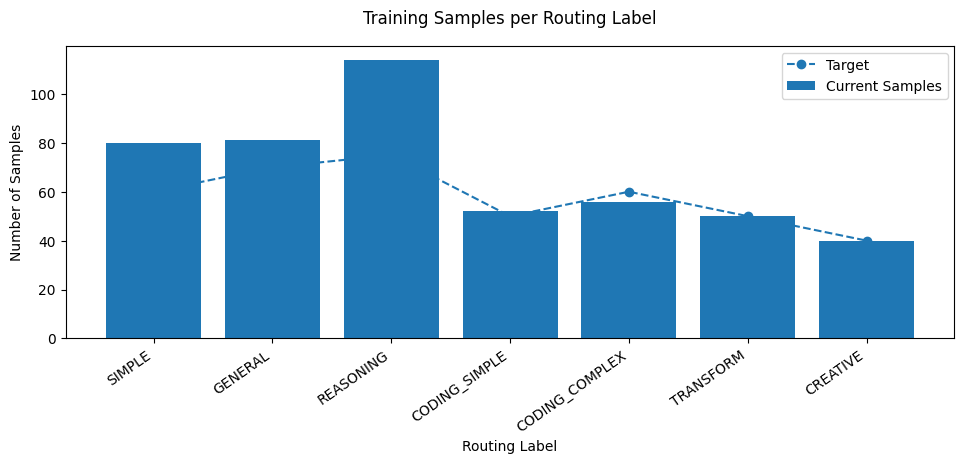


## Real Prompt Routing Test


,ID,Prompt,Route,Confidence,Second Choice,Second Score
0,1,berapa 15 persen dari 500,SIMPLE,0.527,TRANSFORM,0.186
1,2,apa itu HTTP,SIMPLE,0.537,GENERAL,0.301
2,3,jelaskan fungsi docker compose,GENERAL,0.452,CODING_SIMPLE,0.203
3,4,jelaskan cara kerja DNS secara sederhana,CODING_SIMPLE,0.254,GENERAL,0.237
4,5,bandingkan REST dan GraphQL untuk backend apli...,GENERAL,0.480,REASONING,0.231
5,6,lebih baik monolith atau microservice untuk st...,CODING_COMPLEX,0.388,REASONING,0.183
6,7,buat regex untuk validasi email,CODING_SIMPLE,0.879,TRANSFORM,0.080
7,8,buat function python untuk parsing json,CODING_SIMPLE,0.709,CODING_COMPLEX,0.097
8,9,debug kenapa service systemd restart terus dan...,CODING_COMPLEX,0.410,REASONING,0.294
9,10,"review architecture backend saya, analisis bot...",CODING_COMPLEX,0.899,REASONING,0.073



## Routing Confidence


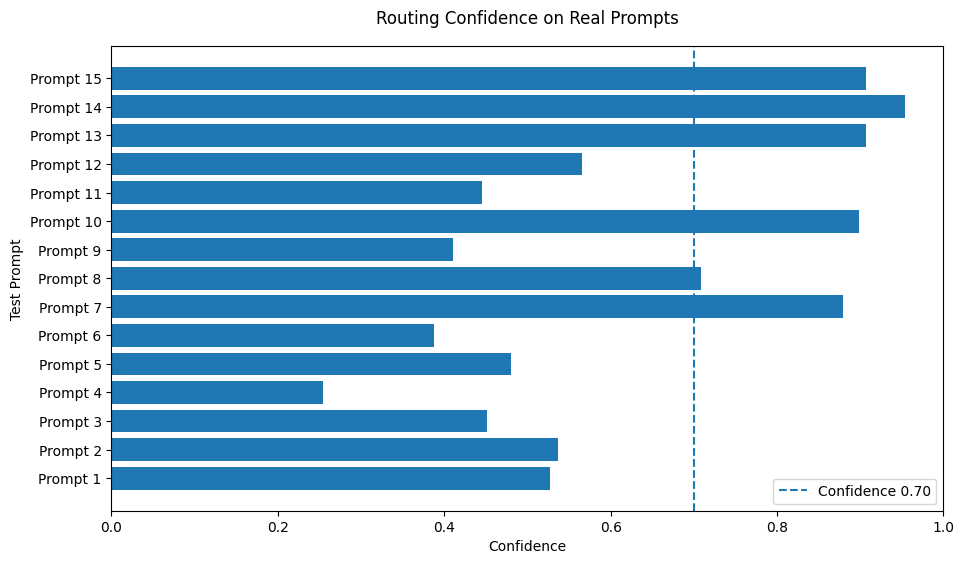


## Confusion Matrix — Fixed Validation


Using evaluation_current from fixed validation set ✅


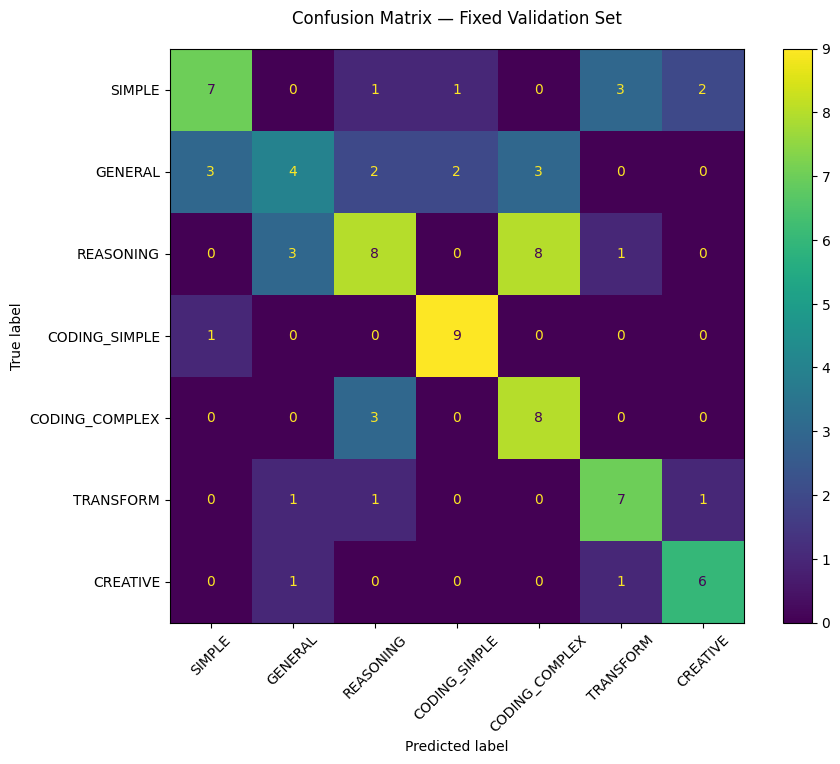


## Normalized Confusion Matrix


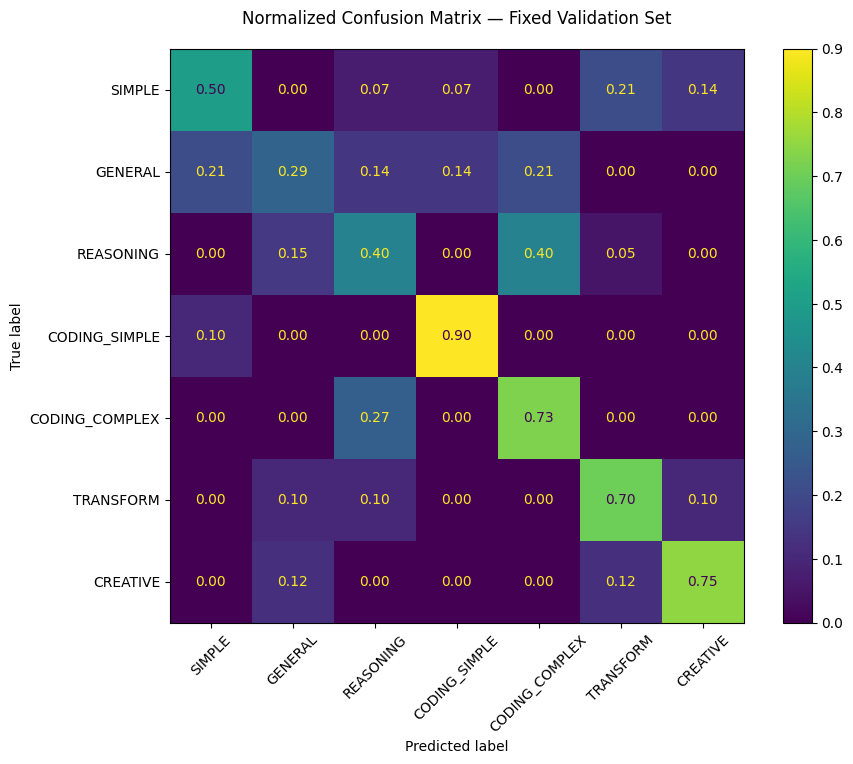


## Predicted Routes on Real Prompts


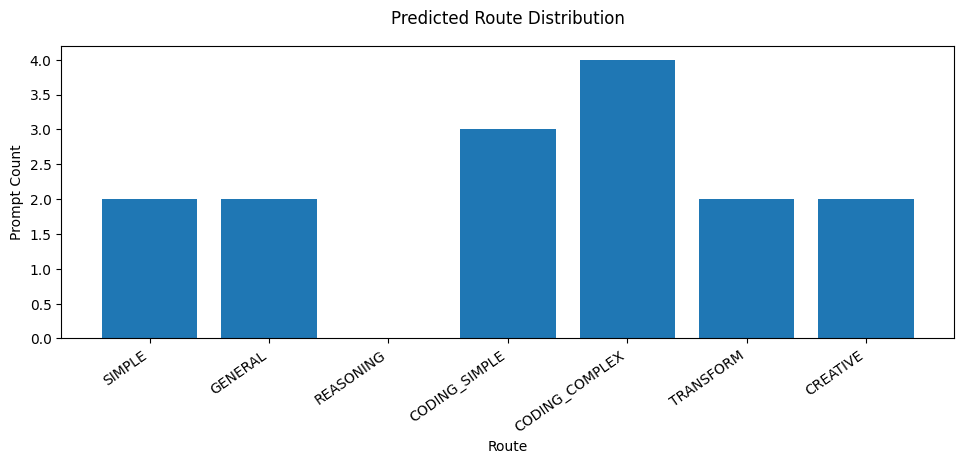


## Auto-Tuning History


,timestamp,samples,target_per_label,accuracy,macro_f1,count_SIMPLE,count_GENERAL,count_REASONING,count_CODING_SIMPLE,count_CODING_COMPLEX,...,target_CREATIVE,best_c,cv_macro_f1,recall_SIMPLE,recall_GENERAL,recall_REASONING,recall_CODING_SIMPLE,recall_CODING_COMPLEX,recall_TRANSFORM,recall_CREATIVE
2,2026-08-23 12:37:25.665214,228,30.0,0.521739,0.450216,38,49,60,5,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-08-23 12:54:45.208393,267,30.0,0.444444,0.437550,43,51,67,23,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-08-23 12:58:13.750565,281,30.0,0.596491,0.623875,43,52,71,30,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2026-08-24 00:25:19.200917,286,30.0,0.655172,0.655757,43,52,73,30,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2026-08-24 00:26:25.215594,288,30.0,0.672414,0.679933,43,52,74,30,29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-08-24 00:27:45.358912,289,30.0,0.655172,0.662208,43,52,74,30,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2026-08-24 01:40:34.091931,375,NaN,0.626667,0.632667,67,67,75,47,30,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2026-08-24 05:32:42.653923,412,NaN,0.542169,0.537799,68,69,89,52,44,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,2026-08-24 06:15:07.152656,429,NaN,0.604651,0.625234,68,70,97,52,52,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,2026-08-24 07:32:14.445961,473,NaN,0.563218,0.579819,80,81,114,52,56,...,40.0,10.0,0.646128,0.5,0.285714,0.4,0.9,0.727273,0.7,0.75


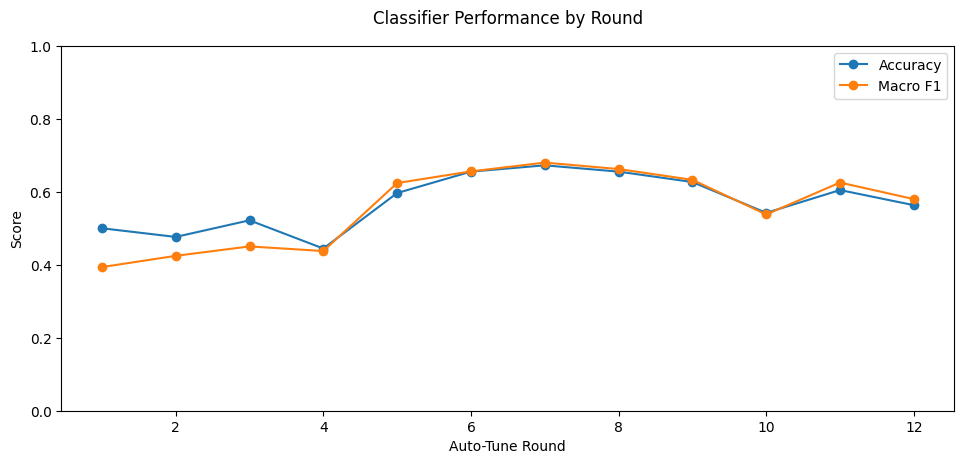


## Report Summary


Labels          : 7
Dataset samples : 473
Dataset target  : 405
Remaining       : 4
Accuracy        : 0.563
Macro F1        : 0.580

REPORT FINISHED


In [44]:
# =========================================================
# CHECK + VISUALIZE LAST ROUND — FIXED + ROBUST VERSION
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown


# =========================================================
# HELPER FUNCTIONS
# =========================================================

def normalize_labels(labels):
    """
    Pastikan LABELS berbentuk list sederhana.
    """
    if labels is None:
        return []

    if isinstance(labels, dict):
        return list(labels.keys())

    if isinstance(labels, pd.Index):
        return labels.tolist()

    if isinstance(labels, np.ndarray):
        return labels.tolist()

    return list(labels)


def get_target_for_label(label):
    """
    Mendukung:
        TARGET_PER_LABEL = 50

    maupun:
        TARGET_PER_LABEL = {
            "simple": 50,
            "complex": 80,
            ...
        }
    """

    if isinstance(TARGET_PER_LABEL, dict):
        return int(
            TARGET_PER_LABEL.get(
                label,
                0
            )
        )

    return int(TARGET_PER_LABEL)


def safe_metric(metrics, key, default=np.nan):
    """
    Ambil metric tanpa menyebabkan KeyError.
    """
    if metrics is None:
        return default

    if not isinstance(metrics, dict):
        return default

    return metrics.get(
        key,
        default
    )


# =========================================================
# VALIDATION
# =========================================================

if "df_balanced" not in globals():
    raise RuntimeError(
        "df_balanced belum tersedia. "
        "Jalankan proses training terlebih dahulu."
    )

if df_balanced is None:
    raise RuntimeError(
        "df_balanced = None."
    )

if not isinstance(df_balanced, pd.DataFrame):
    raise TypeError(
        f"df_balanced harus DataFrame, "
        f"sekarang: {type(df_balanced)}"
    )

if "prompt" not in df_balanced.columns:
    raise KeyError(
        "Kolom 'prompt' tidak ditemukan "
        "di df_balanced."
    )

if "label" not in df_balanced.columns:
    raise KeyError(
        "Kolom 'label' tidak ditemukan "
        "di df_balanced."
    )

if "LABELS" not in globals():
    LABELS = sorted(
        df_balanced[
            "label"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

LABELS = normalize_labels(
    LABELS
)

if len(LABELS) == 0:
    LABELS = sorted(
        df_balanced[
            "label"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


# =========================================================
# 1. HEADER + METRICS
# =========================================================

display(
    Markdown(
        """
# Router Classifier — Last Round Report
"""
    )
)


if (
    "metrics_current" in globals()
    and metrics_current is not None
):

    accuracy_value = safe_metric(
        metrics_current,
        "accuracy"
    )

    macro_f1_value = safe_metric(
        metrics_current,
        "macro_f1"
    )

    test_samples_value = safe_metric(
        metrics_current,
        "test_samples"
    )

    metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Accuracy",
                "Macro F1",
                "Test Samples",
                "Total Dataset",
            ],

            "Value": [
                (
                    round(
                        float(
                            accuracy_value
                        ),
                        3
                    )
                    if pd.notna(
                        accuracy_value
                    )
                    else np.nan
                ),

                (
                    round(
                        float(
                            macro_f1_value
                        ),
                        3
                    )
                    if pd.notna(
                        macro_f1_value
                    )
                    else np.nan
                ),

                test_samples_value,

                len(
                    df_balanced
                ),
            ],
        }
    )

    display(
        metrics_df
    )

else:

    print(
        "Metrics belum tersedia."
    )


# =========================================================
# 2. DATASET DISTRIBUTION
# =========================================================

display(
    Markdown(
        """
## Dataset Distribution
"""
    )
)


# Hitung sample aktual
label_counts = (
    df_balanced[
        "label"
    ]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
    .astype(int)
)


# Buat target sebagai LIST, bukan raw dict
target_values = [
    get_target_for_label(
        label
    )
    for label in LABELS
]


distribution_df = pd.DataFrame(
    {
        "Label": LABELS,

        "Samples": [
            int(
                label_counts.get(
                    label,
                    0
                )
            )
            for label in LABELS
        ],

        "Target": target_values,
    }
)


distribution_df[
    "Remaining"
] = (
    distribution_df[
        "Target"
    ]
    - distribution_df[
        "Samples"
    ]
).clip(
    lower=0
)


distribution_df[
    "Progress %"
] = np.where(

    distribution_df[
        "Target"
    ] > 0,

    (
        distribution_df[
            "Samples"
        ]
        /
        distribution_df[
            "Target"
        ]
        *
        100
    ),

    0
)


distribution_df[
    "Progress %"
] = (
    distribution_df[
        "Progress %"
    ]
    .round(
        1
    )
)


display(
    distribution_df
)


# =========================================================
# 3. PLOT DATASET DISTRIBUTION
# =========================================================

fig = plt.figure(
    figsize=(
        10,
        5
    )
)


x_positions = np.arange(
    len(
        LABELS
    )
)


sample_values = (
    distribution_df[
        "Samples"
    ]
    .to_numpy(
        dtype=float
    )
)


target_values_array = (
    distribution_df[
        "Target"
    ]
    .to_numpy(
        dtype=float
    )
)


plt.bar(
    x_positions,
    sample_values,
    label="Current Samples"
)


# ---------------------------------------------------------
# Jika semua target sama → pakai horizontal line
# Jika target beda per label → plot target per label
# ---------------------------------------------------------

unique_targets = np.unique(
    target_values_array
)


if len(
    unique_targets
) == 1:

    target_line = float(
        unique_targets[
            0
        ]
    )

    plt.axhline(
        target_line,
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Target = "
            f"{int(target_line)}"
        )
    )

else:

    plt.plot(
        x_positions,
        target_values_array,
        marker="o",
        linestyle="--",
        linewidth=1.5,
        label="Target"
    )


plt.title(
    "Training Samples per Routing Label",
    pad=16
)

plt.xlabel(
    "Routing Label"
)

plt.ylabel(
    "Number of Samples"
)

plt.xticks(
    x_positions,
    LABELS,
    rotation=35,
    ha="right"
)

plt.legend()

plt.tight_layout(
    pad=2.0
)

plt.show()

print()


# =========================================================
# 4. REAL PROMPT TEST
# =========================================================

display(
    Markdown(
        """
## Real Prompt Routing Test
"""
    )
)


if (
    "classifier_current"
    not in globals()
    or classifier_current is None
):

    raise RuntimeError(
        "classifier_current belum tersedia."
    )


if (
    "embedding_model"
    not in globals()
    or embedding_model is None
):

    raise RuntimeError(
        "embedding_model belum tersedia."
    )


if (
    "REAL_TEST_PROMPTS"
    not in globals()
    or REAL_TEST_PROMPTS is None
):

    print(
        "REAL_TEST_PROMPTS belum tersedia."
    )

    REAL_TEST_PROMPTS = []


REAL_TEST_PROMPTS = list(
    REAL_TEST_PROMPTS
)


if len(
    REAL_TEST_PROMPTS
) > 0:

    test_embeddings = (
        embedding_model.encode(
            REAL_TEST_PROMPTS,
            batch_size=64,
            show_progress_bar=False,
            normalize_embeddings=True
        )
    )


    predictions = (
        classifier_current.predict(
            test_embeddings
        )
    )


    # -----------------------------------------------------
    # Cek apakah classifier support predict_proba
    # -----------------------------------------------------

    if hasattr(
        classifier_current,
        "predict_proba"
    ):

        probabilities = (
            classifier_current.predict_proba(
                test_embeddings
            )
        )

    else:

        probabilities = None


    real_results = []


    for i, (
        prompt,
        label
    ) in enumerate(
        zip(
            REAL_TEST_PROMPTS,
            predictions
        ),
        start=1
    ):

        result = {
            "ID": i,
            "Prompt": prompt,
            "Route": label,
        }


        if probabilities is not None:

            probs = probabilities[
                i - 1
            ]

            probs = np.asarray(
                probs,
                dtype=float
            )


            confidence = float(
                np.max(
                    probs
                )
            )


            order = np.argsort(
                probs
            )[::-1]


            result[
                "Confidence"
            ] = round(
                confidence,
                3
            )


            if len(
                order
            ) >= 2:

                second_idx = int(
                    order[
                        1
                    ]
                )

                result[
                    "Second Choice"
                ] = (
                    classifier_current
                    .classes_[
                        second_idx
                    ]
                )

                result[
                    "Second Score"
                ] = round(
                    float(
                        probs[
                            second_idx
                        ]
                    ),
                    3
                )

            else:

                result[
                    "Second Choice"
                ] = None

                result[
                    "Second Score"
                ] = np.nan


        else:

            result[
                "Confidence"
            ] = np.nan

            result[
                "Second Choice"
            ] = None

            result[
                "Second Score"
            ] = np.nan


        real_results.append(
            result
        )


    df_real_test = pd.DataFrame(
        real_results
    )


    display(
        df_real_test
    )


else:

    df_real_test = pd.DataFrame(
        columns=[
            "ID",
            "Prompt",
            "Route",
            "Confidence",
            "Second Choice",
            "Second Score"
        ]
    )

    print(
        "Tidak ada REAL_TEST_PROMPTS."
    )


# =========================================================
# 5. CONFIDENCE PLOT
# =========================================================

if (
    len(
        df_real_test
    ) > 0
    and
    "Confidence"
    in df_real_test.columns
    and
    df_real_test[
        "Confidence"
    ]
    .notna()
    .any()
):

    display(
        Markdown(
            """
## Routing Confidence
"""
        )
    )


    fig = plt.figure(
        figsize=(
            10,
            6
        )
    )


    positions = np.arange(
        len(
            df_real_test
        )
    )


    confidence_values = (
        pd.to_numeric(
            df_real_test[
                "Confidence"
            ],
            errors="coerce"
        )
        .fillna(
            0
        )
        .to_numpy()
    )


    plt.barh(
        positions,
        confidence_values
    )


    plt.yticks(
        positions,
        [
            f"Prompt {i}"
            for i
            in df_real_test[
                "ID"
            ]
        ]
    )


    plt.axvline(
        0.70,
        linestyle="--",
        linewidth=1.5,
        label="Confidence 0.70"
    )


    plt.xlim(
        0,
        1
    )


    plt.title(
        "Routing Confidence on Real Prompts",
        pad=16
    )

    plt.xlabel(
        "Confidence"
    )

    plt.ylabel(
        "Test Prompt"
    )

    plt.legend()

    plt.tight_layout(
        pad=2.0
    )

    plt.show()

    print()


# =========================================================
# 6. CONFUSION MATRIX — FIXED VALIDATION
# =========================================================

display(
    Markdown(
        """
## Confusion Matrix — Fixed Validation
"""
    )
)


# ---------------------------------------------------------
# PRIORITY 1:
# gunakan evaluation_current dari training terbaru
# ---------------------------------------------------------

if (
    "evaluation_current" in globals()
    and evaluation_current is not None
):

    y_test_check = np.asarray(
        evaluation_current["y_true"]
    )

    y_pred_check = np.asarray(
        evaluation_current["y_pred"]
    )

    cm = np.asarray(
        evaluation_current[
            "confusion_matrix"
        ]
    )

    cm_labels = list(
        LABELS
    )

    print(
        "Using evaluation_current "
        "from fixed validation set ✅"
    )


# ---------------------------------------------------------
# PRIORITY 2:
# fallback ke router_validation_fixed.csv
# ---------------------------------------------------------

elif (
    "VALIDATION_PATH" in globals()
    and VALIDATION_PATH
    and os.path.exists(
        VALIDATION_PATH
    )
):

    print(
        "evaluation_current tidak tersedia."
    )

    print(
        "Reloading fixed validation set..."
    )

    df_validation_check = pd.read_csv(
        VALIDATION_PATH
    )


    df_validation_check = (
        df_validation_check[
            [
                "prompt",
                "label"
            ]
        ]
        .dropna()
        .copy()
    )


    df_validation_check[
        "prompt"
    ] = (
        df_validation_check[
            "prompt"
        ]
        .astype(str)
        .str.strip()
    )


    df_validation_check[
        "label"
    ] = (
        df_validation_check[
            "label"
        ]
        .astype(str)
        .str.strip()
    )


    df_validation_check = (
        df_validation_check[
            df_validation_check[
                "label"
            ].isin(
                LABELS
            )
        ]
        .reset_index(
            drop=True
        )
    )


    if len(
        df_validation_check
    ) == 0:

        raise RuntimeError(
            "Fixed validation dataset kosong."
        )


    X_validation_check = (
        embedding_model.encode(
            df_validation_check[
                "prompt"
            ].tolist(),
            batch_size=64,
            show_progress_bar=False,
            normalize_embeddings=True
        )
    )


    y_test_check = (
        df_validation_check[
            "label"
        ]
        .to_numpy()
    )


    y_pred_check = (
        classifier_current.predict(
            X_validation_check
        )
    )


    cm_labels = list(
        LABELS
    )


    cm = confusion_matrix(
        y_test_check,
        y_pred_check,
        labels=cm_labels
    )


else:

    raise RuntimeError(
        "Tidak ada evaluation_current "
        "atau fixed validation set."
    )


# ---------------------------------------------------------
# RAW CONFUSION MATRIX
# ---------------------------------------------------------

fig = plt.figure(
    figsize=(
        10,
        8
    )
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cm_labels
)


disp.plot(
    ax=plt.gca(),
    values_format="d",
    xticks_rotation=45
)


plt.title(
    "Confusion Matrix — Fixed Validation Set",
    pad=18
)


plt.tight_layout(
    pad=2.0
)


plt.show()

print()


# =========================================================
# 7. NORMALIZED CONFUSION MATRIX
# =========================================================

display(
    Markdown(
        """
## Normalized Confusion Matrix
"""
    )
)


cm_normalized = confusion_matrix(
    y_test_check,
    y_pred_check,
    labels=cm_labels,
    normalize="true"
)


cm_normalized = np.nan_to_num(
    cm_normalized,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)


fig = plt.figure(
    figsize=(
        10,
        8
    )
)


disp_normalized = (
    ConfusionMatrixDisplay(
        confusion_matrix=cm_normalized,
        display_labels=cm_labels
    )
)


disp_normalized.plot(
    ax=plt.gca(),
    values_format=".2f",
    xticks_rotation=45
)


plt.title(
    "Normalized Confusion Matrix — Fixed Validation Set",
    pad=18
)


plt.tight_layout(
    pad=2.0
)


plt.show()

print()


# =========================================================
# 8. ROUTE DISTRIBUTION — REAL TEST
# =========================================================

display(
    Markdown(
        """
## Predicted Routes on Real Prompts
"""
    )
)


if len(
    df_real_test
) > 0:

    route_counts = (
        df_real_test[
            "Route"
        ]
        .value_counts()
        .reindex(
            LABELS,
            fill_value=0
        )
        .astype(int)
    )


    fig = plt.figure(
        figsize=(
            10,
            5
        )
    )


    x_route = np.arange(
        len(
            LABELS
        )
    )


    plt.bar(
        x_route,
        route_counts.values
    )


    plt.title(
        "Predicted Route Distribution",
        pad=16
    )


    plt.xlabel(
        "Route"
    )

    plt.ylabel(
        "Prompt Count"
    )


    plt.xticks(
        x_route,
        LABELS,
        rotation=35,
        ha="right"
    )


    plt.tight_layout(
        pad=2.0
    )


    plt.show()

    print()


else:

    print(
        "Real prompt result kosong."
    )


# =========================================================
# 9. TUNING HISTORY
# =========================================================

display(
    Markdown(
        """
## Auto-Tuning History
"""
    )
)


if (
    "ROUND_LOG_PATH"
    in globals()
    and
    ROUND_LOG_PATH
    and
    os.path.exists(
        ROUND_LOG_PATH
    )
):

    try:

        history_df = pd.read_csv(
            ROUND_LOG_PATH
        )


        display(
            history_df.tail(
                10
            )
        )


        required_history_columns = {
            "accuracy",
            "macro_f1"
        }


        if (
            len(
                history_df
            ) >= 2
            and
            required_history_columns
            .issubset(
                history_df.columns
            )
        ):

            history_df[
                "accuracy"
            ] = pd.to_numeric(
                history_df[
                    "accuracy"
                ],
                errors="coerce"
            )


            history_df[
                "macro_f1"
            ] = pd.to_numeric(
                history_df[
                    "macro_f1"
                ],
                errors="coerce"
            )


            plot_history = (
                history_df[
                    [
                        "accuracy",
                        "macro_f1"
                    ]
                ]
                .dropna(
                    how="all"
                )
            )


            if len(
                plot_history
            ) >= 2:

                fig = plt.figure(
                    figsize=(
                        10,
                        5
                    )
                )


                rounds = np.arange(
                    1,
                    len(
                        plot_history
                    ) + 1
                )


                plt.plot(
                    rounds,
                    plot_history[
                        "accuracy"
                    ],
                    marker="o",
                    label="Accuracy"
                )


                plt.plot(
                    rounds,
                    plot_history[
                        "macro_f1"
                    ],
                    marker="o",
                    label="Macro F1"
                )


                plt.ylim(
                    0,
                    1
                )


                plt.xlabel(
                    "Auto-Tune Round"
                )


                plt.ylabel(
                    "Score"
                )


                plt.title(
                    "Classifier Performance by Round",
                    pad=16
                )


                plt.legend()


                plt.tight_layout(
                    pad=2.0
                )


                plt.show()


            else:

                print(
                    "History belum punya cukup "
                    "nilai metric valid."
                )


        else:

            print(
                "History baru punya 1 round "
                "atau kolom accuracy/macro_f1 "
                "belum tersedia."
            )


    except Exception as e:

        print(
            "Gagal membaca tuning history:"
        )

        print(
            repr(
                e
            )
        )


else:

    print(
        "Round history belum tersedia."
    )


# =========================================================
# 10. SUMMARY
# =========================================================

display(
    Markdown(
        """
## Report Summary
"""
    )
)


total_samples = int(
    distribution_df[
        "Samples"
    ].sum()
)


total_target = int(
    distribution_df[
        "Target"
    ].sum()
)


total_remaining = int(
    distribution_df[
        "Remaining"
    ].sum()
)


print(
    f"Labels          : {len(LABELS)}"
)

print(
    f"Dataset samples : {total_samples}"
)

print(
    f"Dataset target  : {total_target}"
)

print(
    f"Remaining       : {total_remaining}"
)


if (
    "metrics_current"
    in globals()
    and
    isinstance(
        metrics_current,
        dict
    )
):

    acc = metrics_current.get(
        "accuracy"
    )

    f1 = metrics_current.get(
        "macro_f1"
    )


    if acc is not None:

        print(
            f"Accuracy        : "
            f"{float(acc):.3f}"
        )


    if f1 is not None:

        print(
            f"Macro F1        : "
            f"{float(f1):.3f}"
        )


print()
print(
    "=" * 60
)

print(
    "REPORT FINISHED"
)

print(
    "=" * 60
)